In [1]:
from datasets import load_dataset

/Users/brandonlepine/Repositories/Research_Repositories/smi/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Medical
medqa = load_dataset("GBaker/MedQA-USMLE-4-options")
medmcqa = load_dataset("openlifescienceai/medmcqa")
pubmedqa = load_dataset("qiaojin/PubMedQA", "pqa_labeled")
medqa_adversarial = load_dataset("dynamoai-ml/MedQA-USMLE-4-MultiTurnRobust")
mmlu = load_dataset("cais/mmlu", "clinical_knowledge")  # swap subject name for other subsets

# Legal

lex_glue = load_dataset("coastalcph/lex_glue", "case_hold")

# SWE
humaneval = load_dataset("openai/openai_humaneval")
mbpp = load_dataset("google-research-datasets/mbpp")
ds1000 = load_dataset("xlangai/DS-1000")
bigcodebench = load_dataset("bigcode/bigcodebench")
swebench = load_dataset("princeton-nlp/SWE-bench")
swebench_verified = load_dataset("princeton-nlp/SWE-bench_Verified")
cruxeval = load_dataset("cruxeval-org/cruxeval")

In [3]:
from datasets import load_dataset
import pandas as pd
from pathlib import Path

# --- Medical: MedQA USMLE English, 4-option ---
medqa = load_dataset("GBaker/MedQA-USMLE-4-options")
medqa_test = medqa["test"].to_pandas()

# --- Legal: LegalBench from cloned repo ---
# (assumes you ran: git clone https://github.com/HazyResearch/legalbench.git)
legalbench_dir = Path("/Users/brandonlepine/Repositories/Research_Repositories/smi/legalbench/tasks")
legalbench_tasks = {}
for task_dir in sorted(legalbench_dir.iterdir()):
    if task_dir.is_dir():
        test_file = task_dir / "test.csv"
        if test_file.exists():
            legalbench_tasks[task_dir.name] = pd.read_csv(test_file)
legalbench_df = pd.concat(
    [df.assign(task_name=name) for name, df in legalbench_tasks.items()],
    ignore_index=True
)

# --- SWE: HumanEval + SWE-bench Verified ---
humaneval = load_dataset("openai/openai_humaneval")["test"].to_pandas()
swebench = load_dataset("princeton-nlp/SWE-bench_Verified")["test"].to_pandas()

print(f"MedQA:      {len(medqa_test)} items")
print(f"LegalBench: {len(legalbench_df)} items across {len(legalbench_tasks)} tasks")
print(f"HumanEval:  {len(humaneval)} items")
print(f"SWE-bench:  {len(swebench)} items")

ValueError: No objects to concatenate

In [6]:
task_example = legalbench_dir / "abercrombie"
print(list(task_example.iterdir()))

[PosixPath('/Users/brandonlepine/Repositories/Research_Repositories/smi/legalbench/tasks/abercrombie/llm_rule3_prompt.txt'), PosixPath('/Users/brandonlepine/Repositories/Research_Repositories/smi/legalbench/tasks/abercrombie/train.tsv'), PosixPath('/Users/brandonlepine/Repositories/Research_Repositories/smi/legalbench/tasks/abercrombie/llm_rule1_prompt.txt'), PosixPath('/Users/brandonlepine/Repositories/Research_Repositories/smi/legalbench/tasks/abercrombie/README.MD'), PosixPath('/Users/brandonlepine/Repositories/Research_Repositories/smi/legalbench/tasks/abercrombie/llm_rule2_prompt.txt'), PosixPath('/Users/brandonlepine/Repositories/Research_Repositories/smi/legalbench/tasks/abercrombie/application_prompt.txt'), PosixPath('/Users/brandonlepine/Repositories/Research_Repositories/smi/legalbench/tasks/abercrombie/claude_application_prompt.txt'), PosixPath('/Users/brandonlepine/Repositories/Research_Repositories/smi/legalbench/tasks/abercrombie/claude_prompt.txt'), PosixPath('/Users/bra

In [4]:
legalbench_tasks = {}
for task_dir in sorted(legalbench_dir.iterdir()):
    if task_dir.is_dir():
        tsv_file = task_dir / "train.tsv"
        if tsv_file.exists():
            legalbench_tasks[task_dir.name] = pd.read_csv(tsv_file, sep="\t")

legalbench_df = pd.concat(
    [df.assign(task_name=name) for name, df in legalbench_tasks.items()],
    ignore_index=True
)
print(f"LegalBench: {len(legalbench_df)} items across {len(legalbench_tasks)} tasks")
print(legalbench_df.head())

LegalBench: 835 items across 161 tasks
  index       answer                                               text  \
0     0      generic  The mark "Ivory" for a product made of elephan...   
1     1  descriptive                        The mark "Tasty" for bread.   
2     2   suggestive                   The mark "Caress" for body soap.   
3     3    arbitrary     The mark "Virgin" for wireless communications.   
4     4     fanciful             The mark "Aswelly" for a taxi service.   

     task_name citation circuit contract question document_name bill_title  \
0  abercrombie      NaN     NaN      NaN      NaN           NaN        NaN   
1  abercrombie      NaN     NaN      NaN      NaN           NaN        NaN   
2  abercrombie      NaN     NaN      NaN      NaN           NaN        NaN   
3  abercrombie      NaN     NaN      NaN      NaN           NaN        NaN   
4  abercrombie      NaN     NaN      NaN      NaN           NaN        NaN   

   ... slice policy claim year Docket No.

In [5]:
# --- Medical: MedQA USMLE English, 4-option ---
medqa = load_dataset("GBaker/MedQA-USMLE-4-options")
medqa_test = medqa["test"].to_pandas()

# --- SWE: HumanEval + SWE-bench Verified ---
humaneval = load_dataset("openai/openai_humaneval")["test"].to_pandas()
swebench = load_dataset("princeton-nlp/SWE-bench_Verified")["test"].to_pandas()

print(f"MedQA:      {len(medqa_test)} items")
print(f"LegalBench: {len(legalbench_df)} items across {len(legalbench_tasks)} tasks")
print(f"HumanEval:  {len(humaneval)} items")
print(f"SWE-bench:  {len(swebench)} items")
print(f"\nTotal:      {len(medqa_test) + len(legalbench_df) + len(humaneval) + len(swebench)} items")

# Quick peek at each
print("\n--- MedQA columns ---")
print(medqa_test.columns.tolist())
print(medqa_test.iloc[0])

print("\n--- HumanEval columns ---")
print(humaneval.columns.tolist())

print("\n--- SWE-bench columns ---")
print(swebench.columns.tolist())

MedQA:      1273 items
LegalBench: 835 items across 161 tasks
HumanEval:  164 items
SWE-bench:  500 items

Total:      2772 items

--- MedQA columns ---
['question', 'answer', 'options', 'meta_info', 'answer_idx', 'metamap_phrases']
question           A junior orthopaedic surgery resident is compl...
answer             Tell the attending that he cannot fail to disc...
options            {'A': 'Disclose the error to the patient and p...
meta_info                                                      step1
answer_idx                                                         B
metamap_phrases    [junior orthopaedic surgery resident, completi...
Name: 0, dtype: object

--- HumanEval columns ---
['task_id', 'prompt', 'canonical_solution', 'test', 'entry_point']

--- SWE-bench columns ---
['repo', 'instance_id', 'base_commit', 'patch', 'test_patch', 'problem_statement', 'hints_text', 'created_at', 'version', 'FAIL_TO_PASS', 'PASS_TO_PASS', 'environment_setup_commit', 'difficulty']


In [6]:
# MedQA: USMLE step distribution
print("=== MedQA step distribution ===")
print(medqa_test["meta_info"].value_counts())

# LegalBench: task distribution (how many items per task)
print("\n=== LegalBench items per task (top 20) ===")
print(legalbench_df["task_name"].value_counts().head(20))
print(f"\nMedian items per task: {legalbench_df['task_name'].value_counts().median()}")

# HumanEval: check task_id structure for any difficulty signal
print("\n=== HumanEval task_id examples ===")
print(humaneval["task_id"].head(10).tolist())

# SWE-bench: repo distribution
print("\n=== SWE-bench repo distribution ===")
print(swebench["repo"].value_counts())

=== MedQA step distribution ===
meta_info
step1      679
step2&3    594
Name: count, dtype: int64

=== LegalBench items per task (top 20) ===
task_name
corporate_lobbying                                             10
unfair_tos                                                      9
contract_nli_confidentiality_of_agreement                       8
contract_nli_explicit_identification                            8
contract_nli_inclusion_of_verbally_conveyed_information         8
contract_nli_limited_use                                        8
contract_nli_no_licensing                                       8
contract_nli_notice_on_compelled_disclosure                     8
contract_nli_permissible_acquirement_of_similar_information     8
contract_nli_permissible_copy                                   8
contract_nli_permissible_development_of_similar_information     8
contract_nli_permissible_post-agreement_possession              8
contract_nli_return_of_confidential_information         

In [7]:
# --- Tag MedQA ---
medqa_test["domain"] = "medical"
medqa_test["stratum"] = medqa_test["meta_info"]  # step1 vs step2&3
medqa_test["item_text"] = medqa_test["question"]

# --- Tag LegalBench ---
legalbench_df["domain"] = "legal"
legalbench_df["item_text"] = legalbench_df["text"]

# Check if README files contain reasoning type info
sample_readme = legalbench_dir / "abercrombie" / "README.MD"
print(sample_readme.read_text()[:1000])

# abercrombie

### Determine the *Abercrombie* classification for a mark/product pair.
---



**Source**: Neel Guha

**License**: [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)

**Size (samples)**: 99

**Legal reasoning type**: Rule-application/Rule-conclusion

**Task type**: 5-way classification

## Task description

 A particular mark (e.g. a name for a product or service) is only eligible for trademark protection if it is considered to be *distinctive*. In assessing whether a mark is distinctive, lawyers and judges follow the framework set out in the case *Abercrombie & Fitch Co. v. Hunting World, Inc.*, which enumerates 5 categories of distinctiveness. These categories characterize the relationship between the dictionary definition of the term used in the mark, and the service or product it is being attached to.

- **Generic**: Generic terms are those which connote the basic nature of articles or services, rather than the more individualized characteristics of a product.

In [8]:
import re

# Parse reasoning type from each task's README
reasoning_types = {}
for task_dir in sorted(legalbench_dir.iterdir()):
    if task_dir.is_dir():
        readme = task_dir / "README.MD"
        if not readme.exists():
            readme = task_dir / "README.md"  # case sensitivity
        if readme.exists():
            content = readme.read_text()
            match = re.search(r"\*\*Legal reasoning type\*\*:\s*(.+)", content)
            if match:
                reasoning_types[task_dir.name] = match.group(1).strip()

# Map onto the dataframe
legalbench_df["stratum"] = legalbench_df["task_name"].map(reasoning_types)

print("=== Legal reasoning type distribution ===")
print(legalbench_df["stratum"].value_counts())
print(f"\nUnmapped tasks: {legalbench_df['stratum'].isna().sum()}")

=== Legal reasoning type distribution ===
stratum
Interpretation                      596
Issue-spotting                      106
Rhetorical-analysis                  54
Rule-application/Rule-conclusion     50
Rule-recall                          16
Application/conclusion               13
Name: count, dtype: int64

Unmapped tasks: 0


In [9]:
# --- Tag HumanEval ---
humaneval["domain"] = "swe"
humaneval["stratum"] = "function_level"
humaneval["item_text"] = humaneval["prompt"]

# --- Tag SWE-bench ---
swebench["domain"] = "swe"
swebench["stratum"] = "repo_level"
swebench["item_text"] = swebench["problem_statement"]

# --- Unified summary ---
print("=" * 60)
print("FULL CORPUS SUMMARY")
print("=" * 60)

for domain, label in [("medical", medqa_test), ("legal", legalbench_df), 
                        ("swe", pd.concat([humaneval, swebench]))]:
    print(f"\n--- {domain.upper()} ({len(label)} items) ---")
    print(label["stratum"].value_counts().to_string())

# Quick check: avg item length per domain (proxy for complexity)
print("\n--- Avg item text length (chars) ---")
print(f"MedQA:      {medqa_test['item_text'].str.len().mean():.0f}")
print(f"LegalBench: {legalbench_df['item_text'].str.len().mean():.0f}")
print(f"HumanEval:  {humaneval['item_text'].str.len().mean():.0f}")
print(f"SWE-bench:  {swebench['item_text'].str.len().mean():.0f}")

FULL CORPUS SUMMARY

--- MEDICAL (1273 items) ---
stratum
step1      679
step2&3    594

--- LEGAL (835 items) ---
stratum
Interpretation                      596
Issue-spotting                      106
Rhetorical-analysis                  54
Rule-application/Rule-conclusion     50
Rule-recall                          16
Application/conclusion               13

--- SWE (664 items) ---
stratum
repo_level        500
function_level    164

--- Avg item text length (chars) ---
MedQA:      746
LegalBench: 976
HumanEval:  451
SWE-bench:  1700


In [10]:
# Check what columns each df actually has
print("medqa_test columns:", medqa_test.columns.tolist())
print("legalbench_df columns:", legalbench_df.columns.tolist())
print("humaneval columns:", humaneval.columns.tolist())
print("swebench columns:", swebench.columns.tolist())

medqa_test columns: ['question', 'answer', 'options', 'meta_info', 'answer_idx', 'metamap_phrases', 'domain', 'stratum', 'item_text']
legalbench_df columns: ['index', 'answer', 'text', 'task_name', 'citation', 'circuit', 'contract', 'question', 'document_name', 'bill_title', 'bill_summary', 'company_name', 'company_description', 'parties_are_diverse', 'aic_is_met', 'Citation', 'Paragraph', 'slice', 'policy', 'claim', 'year', 'Docket No.', 'description', 'doctrine', 'case id', 'statute', 'issue', 'domain', 'item_text', 'stratum']
humaneval columns: ['task_id', 'prompt', 'canonical_solution', 'test', 'entry_point', 'domain', 'stratum', 'item_text']
swebench columns: ['repo', 'instance_id', 'base_commit', 'patch', 'test_patch', 'problem_statement', 'hints_text', 'created_at', 'version', 'FAIL_TO_PASS', 'PASS_TO_PASS', 'environment_setup_commit', 'difficulty', 'domain', 'stratum', 'item_text']


In [11]:
# Re-tag everything
medqa_test["domain"] = "medical"
medqa_test["stratum"] = medqa_test["meta_info"]
medqa_test["item_text"] = medqa_test["question"]

legalbench_df["domain"] = "legal"
legalbench_df["item_text"] = legalbench_df["text"]
# stratum already set from the README parsing

humaneval["domain"] = "swe"
humaneval["stratum"] = "function_level"
humaneval["item_text"] = humaneval["prompt"]

swebench["domain"] = "swe"
swebench["stratum"] = "repo_level"
swebench["item_text"] = swebench["problem_statement"]

print("Tags applied. Re-run the sampling cell now.")

Tags applied. Re-run the sampling cell now.


In [12]:
TARGET_PER_STRATUM = 30

def stratified_sample(df, col, n, seed=42):
    pieces = []
    for val, group in df.groupby(col):
        pieces.append(group.sample(n=min(n, len(group)), random_state=seed))
    return pd.concat(pieces, ignore_index=True)

med_sample = stratified_sample(medqa_test, "stratum", TARGET_PER_STRATUM)
legal_sample = stratified_sample(legalbench_df, "stratum", TARGET_PER_STRATUM)

swe_combined = pd.concat([humaneval, swebench], ignore_index=True)
swe_sample = stratified_sample(swe_combined, "stratum", TARGET_PER_STRATUM)

# --- Summary ---
print("=" * 60)
for name, df in [("Medical", med_sample), ("Legal", legal_sample), ("SWE", swe_sample)]:
    print(f"\n--- {name} ({len(df)} items) ---")
    for val in df["stratum"].unique():
        print(f"  {val}: {(df['stratum'] == val).sum()}")

total = len(med_sample) + len(legal_sample) + len(swe_sample)
print(f"\nTOTAL: {total} items")
print(f"x 3 conditions = {total * 3} forward passes")


--- Medical (60 items) ---
  step1: 30
  step2&3: 30

--- Legal (149 items) ---
  Application/conclusion: 13
  Interpretation: 30
  Issue-spotting: 30
  Rhetorical-analysis: 30
  Rule-application/Rule-conclusion: 30
  Rule-recall: 16

--- SWE (60 items) ---
  function_level: 30
  repo_level: 30

TOTAL: 269 items
x 3 conditions = 807 forward passes


In [13]:
# Save originals
med_sample["condition"] = "original"
legal_sample["condition"] = "original"
swe_sample["condition"] = "original"

# Peek at one item per domain to plan the transformations
print("=" * 60)
print("SAMPLE ITEMS FOR CONDITION GENERATION")
print("=" * 60)

print("\n--- MEDICAL ---")
row = med_sample[med_sample["stratum"] == "step1"].iloc[0]
print(f"Question: {row['item_text'][:500]}")
print(f"Options: {row['options']}")
print(f"Answer: {row['answer']}")

print("\n--- LEGAL ---")
row = legal_sample[legal_sample["stratum"] == "Interpretation"].iloc[0]
print(f"Task: {row['task_name']}")
print(f"Text: {row['item_text'][:500]}")
print(f"Answer: {row['answer']}")

print("\n--- SWE (HumanEval) ---")
row = swe_sample[swe_sample["stratum"] == "function_level"].iloc[0]
print(f"Prompt: {row['item_text'][:500]}")


SAMPLE ITEMS FOR CONDITION GENERATION

--- MEDICAL ---
Question: A 40-year old man presents to the clinic with vague upper abdominal pain that has been worsening for the last several days. He says that he often gets similar pain but less severe and that it worsens with meals. The pain sometimes radiates to his back. He recently lost 15 kg (33.6 lb) of weight secondary to his lack of appetite since his last visit 2 months ago. He admits to drinking alcohol almost every night since the age of 17. His temperature is 37.0° C (98.6°F), respirations are 15/min, pul
Options: {'A': 'Pancreas', 'B': 'Jejunum', 'C': 'Duodenum', 'D': 'Gall bladder'}
Answer: Pancreas

--- LEGAL ---
Task: cuad_expiration_date
Text: Either party may terminate this Agreement without cause upon sixty (60) days prior written notice to the other party.
Answer: No

--- SWE (HumanEval) ---
Prompt: 
def can_arrange(arr):
    """Create a function which returns the largest index of an element which
    is not greater than or

In [15]:
import os

# Base save directory
data_dir = Path("/Users/brandonlepine/Repositories/Research_Repositories/smi/benchmark_datasets")

# --- Save Medical ---
medqa_test.to_parquet(data_dir / "medical" / "medqa_usmle_test.parquet", index=False)
med_sample.to_parquet(data_dir / "medical" / "medqa_sample.parquet", index=False)

# --- Save Legal ---
legalbench_df.to_parquet(data_dir / "legal" / "legalbench_full.parquet", index=False)
legal_sample.to_parquet(data_dir / "legal" / "legalbench_sample.parquet", index=False)

# --- Save SWE ---
(data_dir / "swe").mkdir(parents=True, exist_ok=True)
humaneval.to_parquet(data_dir / "swe" / "humaneval_full.parquet", index=False)
swebench.to_parquet(data_dir / "swe" / "swebench_verified_full.parquet", index=False)
swe_sample.to_parquet(data_dir / "swe" / "swe_sample.parquet", index=False)

# Verify
for f in sorted(data_dir.rglob("*.parquet")):
    size = f.stat().st_size / 1024
    print(f"  {f.relative_to(data_dir)}  ({size:.0f} KB)")

print("\nReload later with:")
print('  pd.read_parquet("benchmark_datasets/medical/medqa_sample.parquet")')

  legal/legalbench_full.parquet  (596 KB)
  legal/legalbench_sample.parquet  (138 KB)
  medical/medqa_sample.parquet  (97 KB)
  medical/medqa_usmle_test.parquet  (1467 KB)
  swe/humaneval_full.parquet  (117 KB)
  swe/swe_sample.parquet  (184 KB)
  swe/swebench_verified_full.parquet  (2407 KB)

Reload later with:
  pd.read_parquet("benchmark_datasets/medical/medqa_sample.parquet")


In [16]:
# How much context is actually in the legal items?
row = legal_sample[legal_sample["task_name"] == "cuad_expiration_date"].iloc[0]
print(f"Full text length: {len(row['item_text'])} chars")
print(f"Full text:\n{row['item_text']}")

# And check SWE-bench for the full problem statement
row = swe_sample[swe_sample["stratum"] == "repo_level"].iloc[0]
print(f"\nSWE-bench problem_statement length: {len(row['item_text'])} chars")
print(f"Full text:\n{row['item_text'][:1000]}")

Full text length: 117 chars
Full text:
Either party may terminate this Agreement without cause upon sixty (60) days prior written notice to the other party.

SWE-bench problem_statement length: 1234 chars
Full text:
Pipeline should implement __len__
#### Description

With the new indexing support `pipe[:len(pipe)]` raises an error.

#### Steps/Code to Reproduce

```python
from sklearn import svm
from sklearn.datasets import samples_generator
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
from sklearn.pipeline import Pipeline

# generate some data to play with
X, y = samples_generator.make_classification(
    n_informative=5, n_redundant=0, random_state=42)

anova_filter = SelectKBest(f_regression, k=5)
clf = svm.SVC(kernel='linear')
pipe = Pipeline([('anova', anova_filter), ('svc', clf)])

len(pipe)
```

#### Versions

```
System:
    python: 3.6.7 | packaged by conda-forge | (default, Feb 19 2019, 18:37:23)  [GCC 4.2.1 Compatible C

In [18]:
task_stats = legalbench_df.groupby("task_name").apply(
    lambda g: pd.Series({
        "n_items": len(g),
        "n_unique_answers": g["answer"].nunique(),
        "avg_answer_len": g["answer"].astype(str).str.len().mean(),
        "avg_text_len": g["item_text"].astype(str).str.len().mean(),
        "reasoning_type": g["stratum"].iloc[0]
    })
).reset_index()

task_stats["format"] = "classification"
task_stats.loc[
    (task_stats["n_unique_answers"] > 5) | (task_stats["avg_answer_len"] > 50),
    "format"
] = "open_generation"

print("=== Task format distribution ===")
print(task_stats["format"].value_counts())
print()

print("=== Reasoning type × Format ===")
ct = task_stats.groupby(["reasoning_type", "format"]).size().unstack(fill_value=0)
print(ct)
print()

print("=== Open generation tasks ===")
open_tasks = task_stats[task_stats["format"] == "open_generation"].sort_values("reasoning_type")
for _, row in open_tasks.iterrows():
    print(f"  {row['task_name']:50s} | {row['reasoning_type']:35s} | {int(row['n_items'])} items | avg answer len: {row['avg_answer_len']:.0f}")

=== Task format distribution ===
format
classification     155
open_generation      5
Name: count, dtype: int64

=== Reasoning type × Format ===
format                            classification  open_generation
reasoning_type                                                   
Application/conclusion                         3                0
Interpretation                               116                2
Issue-spotting                                17                0
Rhetorical-analysis                            6                3
Rule-application/Rule-conclusion               9                0
Rule-recall                                    4                0

=== Open generation tasks ===
  ssla_individual_defendants                         | Interpretation                      | 3 items | avg answer len: 65
  unfair_tos                                         | Interpretation                      | 9 items | avg answer len: 15
  definition_extraction                             

In [19]:
# Map format onto the full legalbench_df
task_format_map = task_stats.set_index("task_name")["format"].to_dict()
legalbench_df["format"] = legalbench_df["task_name"].map(task_format_map)

# Take ALL open-generation items
legal_open = legalbench_df[legalbench_df["format"] == "open_generation"].copy()

# Sample from classification, stratified by reasoning type
legal_classif = legalbench_df[legalbench_df["format"] == "classification"].copy()
legal_classif_sample = stratified_sample(legal_classif, "stratum", TARGET_PER_STRATUM)

# Combine
legal_sample = pd.concat([legal_open, legal_classif_sample], ignore_index=True)

# Summary
print("=== Legal sample ===")
print(f"Total: {len(legal_sample)} items\n")
print("--- By format ---")
print(legal_sample["format"].value_counts().to_string())
print()
print("--- By reasoning type × format ---")
for fmt in ["open_generation", "classification"]:
    subset = legal_sample[legal_sample["format"] == fmt]
    print(f"\n  {fmt} ({len(subset)} items):")
    for val in sorted(subset["stratum"].unique()):
        print(f"    {val}: {(subset['stratum'] == val).sum()}")

=== Legal sample ===
Total: 183 items

--- By format ---
format
classification     149
open_generation     34

--- By reasoning type × format ---

  open_generation (34 items):
    Interpretation: 12
    Rhetorical-analysis: 22

  classification (149 items):
    Application/conclusion: 13
    Interpretation: 30
    Issue-spotting: 30
    Rhetorical-analysis: 30
    Rule-application/Rule-conclusion: 30
    Rule-recall: 16


In [21]:
total = len(med_sample) + len(legal_sample) + len(swe_sample)
print("=" * 60)
print("FINAL SAMPLED CORPUS")
print("=" * 60)
print(f"  Medical:  {len(med_sample)} items")
print(f"  Legal:    {len(legal_sample)} items ({(legal_sample['format']=='open_generation').sum()} open + {(legal_sample['format']=='classification').sum()} classif)")
print(f"  SWE:      {len(swe_sample)} items")
print(f"  TOTAL:    {total} items")
print(f"  × 3 conditions = {total * 3} forward passes")

# Re-save with updated legal sample
legal_sample.to_parquet("/Users/brandonlepine/Repositories/Research_Repositories/smi/benchmark_datasets/legal/legalbench_sample.parquet", index=False)
print("\nLegal sample re-saved.")

FINAL SAMPLED CORPUS
  Medical:  60 items
  Legal:    183 items (34 open + 149 classif)
  SWE:      60 items
  TOTAL:    303 items
  × 3 conditions = 909 forward passes

Legal sample re-saved.


In [22]:
import dotenv
dotenv.load_dotenv()
import os
print("OPENAI_API_KEY set:", bool(os.getenv("OPENAI_API_KEY")))

OPENAI_API_KEY set: True


## Few Shot Examples for Generating the Abstract Prompt Condition and the Adversarial Prompt Condition

In [ ]:

# ---- medical (abstract) ----

med_qa_example_original_1 = """A 65-year-old woman presents with sudden onset of right-sided weakness and difficulty speaking. CT scans show no hemorrhage. 
What is the most appropriate initial treatment? A) Tissue plasminogen activator B) Aspirin C) Heparin D) Warfarin
"""

med_qa_example_abstract_1 = """An individual presents with sudden loss of Function A on one side of their body and impairment of Function B. 
Imaging Test X shows the absense of Condition Y. What is the most appropriate initial treatment? A) Intervention P B) Intervention Q C) Intervention R D) Intervention S
"""
med_qa_example_original_2 = """ A 30-year-old man presents with polyuria, polydipsia, and weight loss. Fasting blood glucose is 280 mg/dL. 
Which autoantiboyd is most likely positive? A) Anti-GAD65 B) Anti-Smith C) Anti-centromere D) Anti-mitochondrial
"""
med_qa_example_abstract_2 = """ A person presents with Symptom X, Symptom Y, and Symptom Z. Laboratory Test A shows a highly elevated value of measurement B. 
Which marker is most likely to be detected? A) Marker P B) Marker Q C) Marker R D) Marker S
"""


# ---- medical (adversarial) ----

# ---- legal (abstract) ----

# ---- legal (adversarial) ----



In [ ]:
import json
import os
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
MODEL = "o4-mini-2025-04-16"

DEVELOPER_MSG = (
    "You are an expert research assistant helping design stimuli for a "
    "mechanistic interpretability study. You will be given a benchmark item "
    "from a specific domain and asked to produce a transformed version. "
    "You must return ONLY valid JSON with the specified fields — no markdown, "
    "no commentary, no backticks."
)

def call_o4(prompt):
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "developer", "content": DEVELOPER_MSG},
            {"role": "user", "content": prompt},
        ],
    )
    text = resp.choices[0].message.content.strip()
    if text.startswith("```"):
        text = text.split("\n", 1)[1].rsplit("```", 1)[0]
    return json.loads(text)

# === DRY RUN: 1 item per domain × 2 conditions ===

# --- MEDICAL ---
row = med_sample.iloc[0]
med_abstract_prompt = f"""Transform this medical question into an ABSTRACT version that preserves 
the exact logical/reasoning structure but REMOVES all domain-specific medical knowledge.

Rules:
- Replace all disease names, drug names, anatomical terms, lab values, and clinical 
  signs with generic placeholders (e.g., "Condition X", "Substance Y", "Organ Z").
- Preserve the logical chain and answer structure (same number of options, same correct position).
- The abstract version should be UNSOLVABLE using medical knowledge.

Return JSON:
{{"abstract_text": "...", "abstract_options": {{"A": "...", "B": "...", "C": "...", "D": "..."}}, "abstract_answer_idx": "...", "mappings": {{...}}}}

ORIGINAL:
Question: {row['question']}
Options: {json.dumps(row['options'])}
Answer: {row['answer']} ({row['answer_idx']})"""

med_adversarial_prompt = f"""Create an ADVERSARIAL version of this medical question that introduces 
subtle but specific factual errors that would lead toward a WRONG answer.

Rules:
- Change 1-2 medical facts (swap a mechanism, invert a contraindication, etc.)
- Should LOOK plausible but contain errors an expert would catch.
- The correct answer should now appear incorrect given the modified facts.

Return JSON:
{{"adversarial_text": "...", "adversarial_options": {{"A": "...", "B": "...", "C": "...", "D": "..."}}, "original_correct_idx": "...", "adversarial_lure_idx": "...", "modifications": [...]}}

ORIGINAL:
Question: {row['question']}
Options: {json.dumps(row['options'])}
Answer: {row['answer']} ({row['answer_idx']})"""

print("=" * 60)
print("MEDICAL — ORIGINAL")
print("=" * 60)
print(f"Q: {row['question'][:300]}...")
print(f"A: {row['answer']} ({row['answer_idx']})")

print("\n--- ABSTRACT ---")
med_abs = call_o4(med_abstract_prompt)
print(json.dumps(med_abs, indent=2)[:1000])

print("\n--- ADVERSARIAL ---")
med_adv = call_o4(med_adversarial_prompt)
print(json.dumps(med_adv, indent=2)[:1000])

# --- LEGAL ---
row = legal_sample[legal_sample["stratum"] == "Rule-application/Rule-conclusion"].iloc[0]

legal_abstract_prompt = f"""Transform this legal task item into an ABSTRACT version that preserves 
the exact logical/reasoning structure but REMOVES all domain-specific legal knowledge.

Rules:
- Replace all legal terms, statute references, case names, contract clauses with generic placeholders.
- Preserve the task structure and answer exactly.

Return JSON:
{{"abstract_text": "...", "abstract_answer": "...", "mappings": {{...}}}}

ORIGINAL:
Task: {row['task_name']}
Text: {row['item_text']}
Answer: {row['answer']}"""

legal_adversarial_prompt = f"""Create an ADVERSARIAL version of this legal task item that introduces 
subtle errors in legal reasoning that would flip the correct answer.

Rules:
- Subtly change wording to negate meaning, introduce a qualifier, or swap a legal standard.
- Keep the same task structure and style.

Return JSON:
{{"adversarial_text": "...", "adversarial_answer": "...", "original_answer": "...", "modifications": [...]}}

ORIGINAL:
Task: {row['task_name']}
Text: {row['item_text']}
Answer: {row['answer']}"""

print("\n" + "=" * 60)
print("LEGAL — ORIGINAL")
print("=" * 60)
print(f"Task: {row['task_name']}")
print(f"Text: {row['item_text'][:300]}")
print(f"Answer: {row['answer']}")

print("\n--- ABSTRACT ---")
leg_abs = call_o4(legal_abstract_prompt)
print(json.dumps(leg_abs, indent=2)[:1000])

print("\n--- ADVERSARIAL ---")
leg_adv = call_o4(legal_adversarial_prompt)
print(json.dumps(leg_adv, indent=2)[:1000])

# --- SWE ---
row = swe_sample[swe_sample["stratum"] == "function_level"].iloc[0]

swe_abstract_prompt = f"""Transform this programming item into an ABSTRACT version that preserves 
the logical/algorithmic structure but REMOVES all programming-specific knowledge.

Rules:
- Replace library names, API calls, function signatures, syntax with generic pseudocode descriptions.
- The abstract version should read as a logic puzzle understandable to a non-programmer.

Return JSON:
{{"abstract_text": "...", "mappings": {{...}}}}

ORIGINAL:
Task ID: {row.get('task_id', 'N/A')}
Prompt: {row['item_text']}"""

swe_adversarial_prompt = f"""Create an ADVERSARIAL version of this programming item that introduces 
subtle bugs or misleading elements in the description.

Rules:
- Swap "greater than" with "greater than or equal to", change an edge case, or alter 
  expected return values for boundary inputs.
- Should be plausible and hard to catch on first reading.

Return JSON:
{{"adversarial_text": "...", "modifications": [...]}}

ORIGINAL:
Task ID: {row.get('task_id', 'N/A')}
Prompt: {row['item_text']}"""

print("\n" + "=" * 60)
print("SWE — ORIGINAL")
print("=" * 60)
print(f"Task: {row.get('task_id', 'N/A')}")
print(f"Prompt: {row['item_text'][:300]}")

print("\n--- ABSTRACT ---")
swe_abs = call_o4(swe_abstract_prompt)
print(json.dumps(swe_abs, indent=2)[:1000])

print("\n--- ADVERSARIAL ---")
swe_adv = call_o4(swe_adversarial_prompt)
print(json.dumps(swe_adv, indent=2)[:1000])

In [ ]:
# or whatever you named it in .env

# Option A: pass token directly to from_pretrained
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
    token=hf_token,
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=hf_token)

In [2]:
import torch
import os
from transformers import AutoModelForCausalLM, AutoTokenizer

from dotenv import load_dotenv


load_dotenv()
hf_token = os.getenv("HF_TOKEN")  

MODEL_ID = "/Users/brandonlepine/Repositories/Research_Repositories/smi/models/llama2-7b"

# Do you have access to this gated model? If not, you'll need to:
# 1. Accept the license at https://huggingface.co/meta-llama/Llama-2-7b-hf
# 2. Set your HF token: huggingface-cli login

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
print(f"Tokenizer loaded: vocab size {tokenizer.vocab_size}")

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
)
print(f"Model loaded: {sum(p.numel() for p in model.parameters()) / 1e9:.1f}B params")

# Quick sanity check
inputs = tokenizer("The capital of France is", return_tensors="pt").to(device)
with torch.no_grad():
    logits = model(**inputs).logits
    next_token = tokenizer.decode(logits[0, -1].argmax())
print(f"Sanity check: 'The capital of France is' → '{next_token}'")

Tokenizer loaded: vocab size 32000
Device: mps


Loading weights: 100%|██████████| 291/291 [00:05<00:00, 58.02it/s] 


Model loaded: 6.7B params
Sanity check: 'The capital of France is' → 'a'


In [4]:

import json
from pathlib import Path

records = []
with open("/Users/brandonlepine/Repositories/Research_Repositories/smi/results/patching/medical_layer_patching.jsonl") as f:
    for line in f:
        records.append(json.loads(line))

for r in records[:20]:
    kl = r["kl_by_layer"]
    is_flat = (max(kl) - min(kl)) < 0.01
    print(f"item {r['item_idx']:2d} | Δlen={r['len_diff']:2d} | "
          f"KL range=[{min(kl):.3f}, {max(kl):.3f}] | "
          f"{'FLAT ❌' if is_flat else 'VARIABLE ✓'}")

item  0 | Δlen=11 | KL range=[10.819, 10.819] | FLAT ❌
item  1 | Δlen= 7 | KL range=[6.941, 6.949] | FLAT ❌
item  2 | Δlen= 2 | KL range=[0.000, 0.019] | VARIABLE ✓
item  3 | Δlen= 2 | KL range=[0.000, 0.042] | VARIABLE ✓
item  4 | Δlen=14 | KL range=[10.132, 10.146] | VARIABLE ✓
item  5 | Δlen= 1 | KL range=[0.000, 0.007] | FLAT ❌
item  6 | Δlen= 0 | KL range=[0.000, 0.000] | FLAT ❌
item  7 | Δlen= 1 | KL range=[0.000, 0.003] | FLAT ❌
item  8 | Δlen=26 | KL range=[10.608, 10.608] | FLAT ❌
item  9 | Δlen= 6 | KL range=[8.416, 8.416] | FLAT ❌
item 10 | Δlen= 1 | KL range=[0.000, 0.061] | VARIABLE ✓
item 11 | Δlen= 5 | KL range=[10.733, 10.733] | FLAT ❌
item 12 | Δlen= 1 | KL range=[0.000, 0.012] | VARIABLE ✓
item 13 | Δlen= 4 | KL range=[5.796, 5.796] | FLAT ❌
item 14 | Δlen=25 | KL range=[11.139, 11.156] | VARIABLE ✓
item 15 | Δlen= 3 | KL range=[10.852, 10.852] | FLAT ❌
item 16 | Δlen= 1 | KL range=[0.000, 0.002] | FLAT ❌
item 17 | Δlen= 9 | KL range=[32.987, 32.987] | FLAT ❌
item 18 

In [6]:
import json
import numpy as np

for domain in ["medical", "legal", "swe"]:
    records = []
    with open(f"/Users/brandonlepine/Repositories/Research_Repositories/smi/results/patching/{domain}_layer_patching.jsonl") as f:
        for line in f:
            records.append(json.loads(line))
    
    # Per-item mean KL
    mean_kls = [np.mean(r["kl_by_layer"]) for r in records]
    
    print(f"\n=== {domain.upper()} ({len(records)} items) ===")
    print(f"  Median item KL:  {np.median(mean_kls):.4f}")
    print(f"  Mean item KL:    {np.mean(mean_kls):.4f}")
    print(f"  Items with KL > 1.0: {sum(1 for k in mean_kls if k > 1.0)}")
    print(f"  Items with KL < 0.01: {sum(1 for k in mean_kls if k < 0.01)}")
    
    # Distribution
    pcts = [r.get("pct_changed", 0) for r in records]
    print(f"  Median % tokens changed: {np.median(pcts):.1f}%")
    
    # Show the outliers
    sorted_items = sorted(zip(mean_kls, records), key=lambda x: x[0], reverse=True)
    print(f"  Top 5 KL items:")
    for kl, r in sorted_items[:5]:
        print(f"    item {r['item_idx']:3d} | KL={kl:.4f} | {r.get('pct_changed', '?')}% changed | {r['stratum']}")
    print(f"  Bottom 5 KL items:")
    for kl, r in sorted_items[-5:]:
        print(f"    item {r['item_idx']:3d} | KL={kl:.6f} | {r.get('pct_changed', '?')}% changed | {r['stratum']}")


=== MEDICAL (54 items) ===
  Median item KL:  0.0005
  Mean item KL:    0.1203
  Items with KL > 1.0: 3
  Items with KL < 0.01: 46
  Median % tokens changed: 4.7%
  Top 5 KL items:
    item  15 | KL=1.4130 | 2.2% changed | step1
    item  34 | KL=1.3557 | 1.4% changed | step2&3
    item  52 | KL=1.1935 | 4.3% changed | step2&3
    item  39 | KL=0.9159 | 3.0% changed | step2&3
    item  58 | KL=0.9063 | 3.0% changed | step2&3
  Bottom 5 KL items:
    item   4 | KL=0.000025 | 0.8% changed | step1
    item  22 | KL=0.000012 | 1.1% changed | step1
    item  33 | KL=0.000010 | 1.7% changed | step2&3
    item  25 | KL=0.000005 | 2.0% changed | step1
    item  30 | KL=0.000001 | 0.5% changed | step2&3

=== LEGAL (129 items) ===
  Median item KL:  0.0201
  Mean item KL:    1.3764
  Items with KL > 1.0: 26
  Items with KL < 0.01: 50
  Median % tokens changed: 8.1%
  Top 5 KL items:
    item  91 | KL=25.2218 | 13.7% changed | Issue-spotting
    item  57 | KL=14.5197 | 3.7% changed | Interpretat


MEDICAL: 51 clean / 3 filtered (>20.0% changed)

LEGAL: 104 clean / 25 filtered (>20.0% changed)

SWE: 33 clean / 20 filtered (>20.0% changed)


FileNotFoundError: [Errno 2] No such file or directory: 'results/patching/layer_patching_filtered.png'

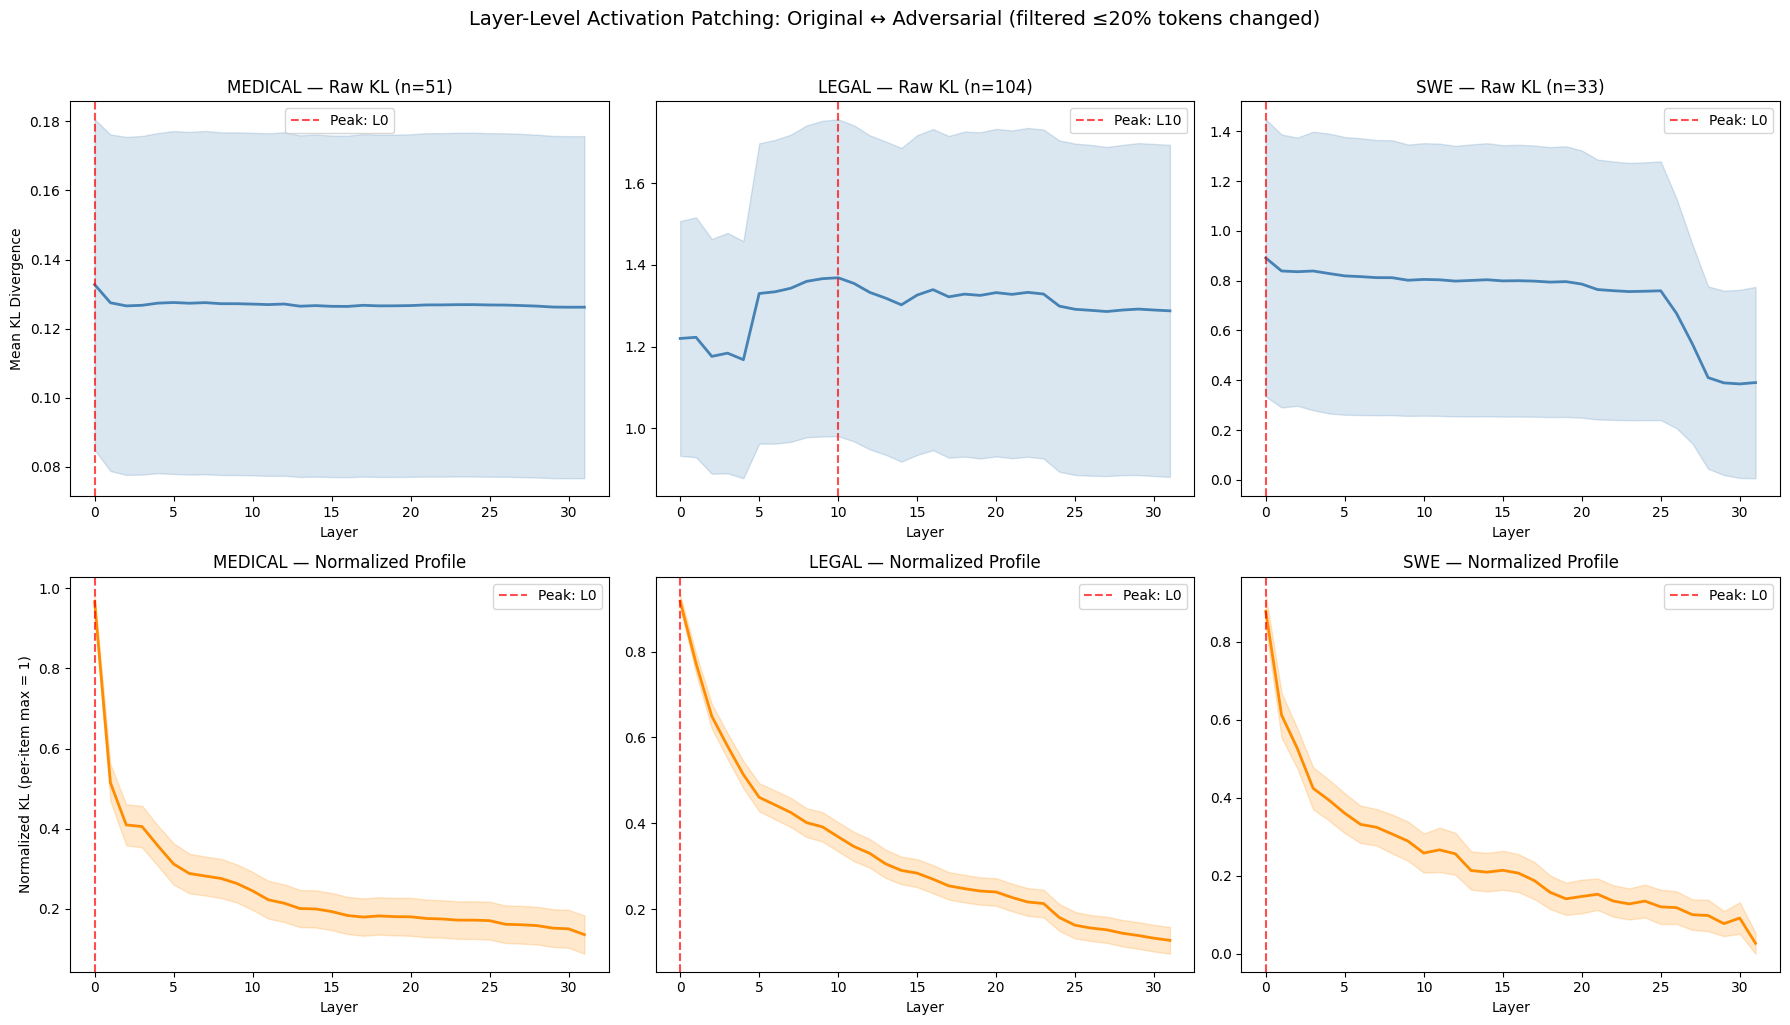

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import json

MAX_PCT_CHANGED = 20.0  # filter out sloppy adversarials

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, domain in enumerate(["medical", "legal", "swe"]):
    records = []
    with open(f"/Users/brandonlepine/Repositories/Research_Repositories/smi/results/patching/{domain}_layer_patching.jsonl") as f:
        for line in f:
            records.append(json.loads(line))
    
    clean = [r for r in records if r.get("pct_changed", 0) <= MAX_PCT_CHANGED]
    dirty = [r for r in records if r.get("pct_changed", 0) > MAX_PCT_CHANGED]
    
    print(f"\n{domain.upper()}: {len(clean)} clean / {len(dirty)} filtered (>{MAX_PCT_CHANGED}% changed)")
    
    # --- Top row: raw KL by layer ---
    ax = axes[0, col]
    kl_matrix = np.array([r["kl_by_layer"] for r in clean])
    mean_kl = kl_matrix.mean(axis=0)
    sem_kl = kl_matrix.std(axis=0) / np.sqrt(len(clean))
    layers = np.arange(32)
    
    ax.plot(layers, mean_kl, color="steelblue", linewidth=2)
    ax.fill_between(layers, mean_kl - sem_kl, mean_kl + sem_kl, alpha=0.2, color="steelblue")
    ax.set_title(f"{domain.upper()} — Raw KL (n={len(clean)})")
    ax.set_xlabel("Layer")
    if col == 0:
        ax.set_ylabel("Mean KL Divergence")
    
    peak = int(np.argmax(mean_kl))
    ax.axvline(peak, color="red", linestyle="--", alpha=0.7, label=f"Peak: L{peak}")
    ax.legend()
    
    # --- Bottom row: normalized KL profiles ---
    # Divide each item's KL vector by its max, so we're comparing SHAPE not magnitude
    ax = axes[1, col]
    normed = []
    for r in clean:
        kl = np.array(r["kl_by_layer"])
        if kl.max() > 0:
            normed.append(kl / kl.max())
    
    normed = np.array(normed)
    mean_normed = normed.mean(axis=0)
    sem_normed = normed.std(axis=0) / np.sqrt(len(normed))
    
    ax.plot(layers, mean_normed, color="darkorange", linewidth=2)
    ax.fill_between(layers, mean_normed - sem_normed, mean_normed + sem_normed, 
                     alpha=0.2, color="darkorange")
    ax.set_title(f"{domain.upper()} — Normalized Profile")
    ax.set_xlabel("Layer")
    if col == 0:
        ax.set_ylabel("Normalized KL (per-item max = 1)")
    
    peak_norm = int(np.argmax(mean_normed))
    ax.axvline(peak_norm, color="red", linestyle="--", alpha=0.7, label=f"Peak: L{peak_norm}")
    ax.legend()

fig.suptitle("Layer-Level Activation Patching: Original ↔ Adversarial (filtered ≤20% tokens changed)", 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("results/patching/layer_patching_filtered.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n" + "="*60)
print("FILTERED SUMMARY")
print("="*60)

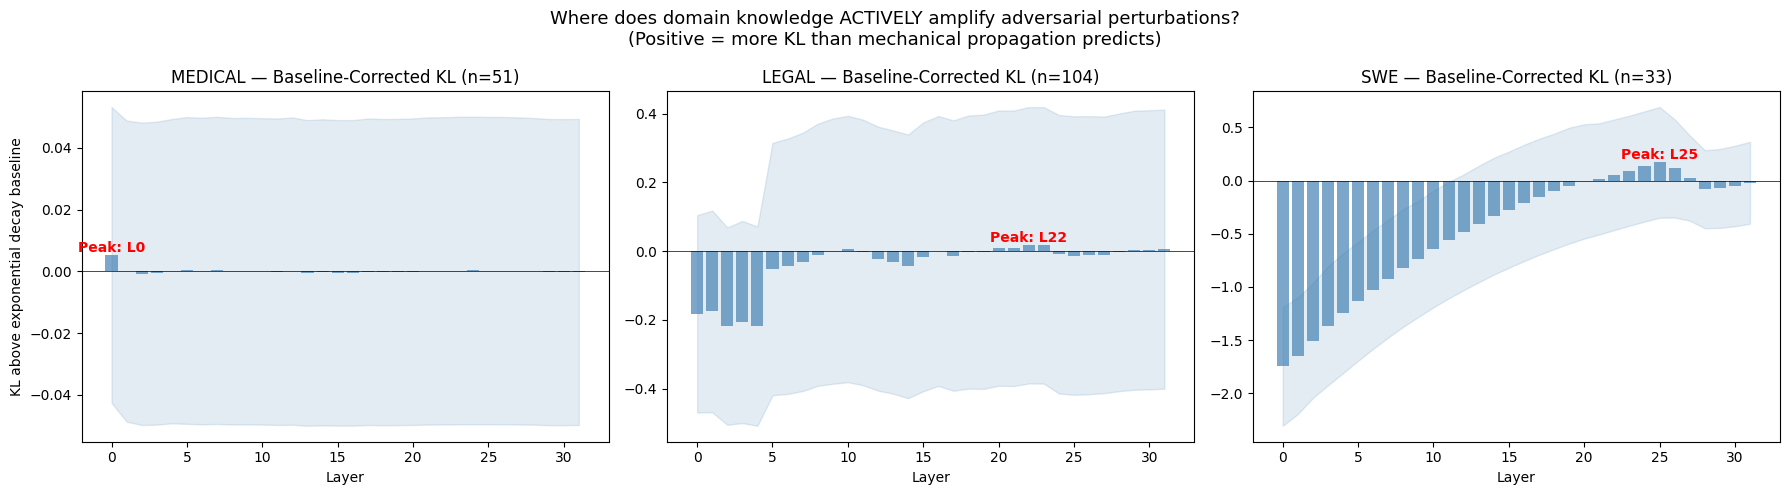

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import json

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Load all domains
domain_data = {}
for domain in ["medical", "legal", "swe"]:
    records = []
    with open(f"/Users/brandonlepine/Repositories/Research_Repositories/smi/results/patching/{domain}_layer_patching.jsonl") as f:
        for line in f:
            records.append(json.loads(line))
    clean = [r for r in records if r.get("pct_changed", 0) <= 20.0]
    domain_data[domain] = clean

# Use MEDICAL as the "baseline" profile since it has the least
# domain-specific signal (smallest KL), or compute a pooled baseline
# Actually better: normalize each domain against its own monotonic trend

for col, domain in enumerate(["medical", "legal", "swe"]):
    ax = axes[col]
    clean = domain_data[domain]
    
    kl_matrix = np.array([r["kl_by_layer"] for r in clean])
    mean_kl = kl_matrix.mean(axis=0)
    
    # Fit a monotonic decay baseline: KL(layer) = a * exp(-b * layer)
    # This captures the "more downstream layers = more effect" artifact
    layers = np.arange(32)
    
    # Use log-linear fit on layers where we expect pure decay (skip L0-1)
    # to estimate what the profile WOULD look like without domain-specific computation
    log_kl = np.log(mean_kl + 1e-10)
    
    # Fit line to log(KL) vs layer for the last 15 layers (where it should be pure decay)
    fit_layers = np.arange(17, 32)
    fit_vals = log_kl[17:32]
    slope, intercept = np.polyfit(fit_layers, fit_vals, 1)
    baseline = np.exp(intercept + slope * layers)
    
    # Residual = actual - baseline (positive = MORE effect than expected)
    residual = mean_kl - baseline
    sem = kl_matrix.std(axis=0) / np.sqrt(len(clean))
    
    ax.bar(layers, residual, color="steelblue", alpha=0.7)
    ax.fill_between(layers, residual - sem, residual + sem, alpha=0.15, color="steelblue")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_xlabel("Layer")
    ax.set_title(f"{domain.upper()} — Baseline-Corrected KL (n={len(clean)})")
    if col == 0:
        ax.set_ylabel("KL above exponential decay baseline")
    
    # Mark peak residual
    peak = int(np.argmax(residual))
    ax.annotate(f"Peak: L{peak}", xy=(peak, residual[peak]), fontsize=10,
                ha="center", va="bottom", color="red", fontweight="bold")

fig.suptitle("Where does domain knowledge ACTIVELY amplify adversarial perturbations?\n(Positive = more KL than mechanical propagation predicts)", 
             fontsize=13)
plt.tight_layout()
plt.savefig("/Users/brandonlepine/Repositories/Research_Repositories/smi/results/patching/baseline_corrected_kl.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
import json
from pathlib import Path
from collections import Counter

# Single-category results
surgical_path = Path("/Users/brandonlepine/Repositories/Research_Repositories/smi/benchmark_datasets/surgical_abstractions/medical_surgical.jsonl")
counts = Counter()
with open(surgical_path) as f:
    for line in f:
        rec = json.loads(line)
        if rec["success"]:
            counts[rec["category"]] += 1
print("Single-category counts:")
for cat, n in sorted(counts.items()):
    print(f"  {cat}: {n}")

# Composed results
composed_path = Path("/Users/brandonlepine/Repositories/Research_Repositories/smi/benchmark_datasets/surgical_abstractions/medical_composed.jsonl")
combo_counts = Counter()
with open(composed_path) as f:
    for line in f:
        rec = json.loads(line)
        combo_counts[rec["combination_name"]] += 1
print(f"\nComposed conditions:")
for name, n in sorted(combo_counts.items()):
    print(f"  {name}: {n}")

Single-category counts:
  entity: 60
  procedure: 60
  property: 60
  relation: 60

Composed conditions:
  entity+procedure: 60
  entity+property: 60
  entity+property+procedure: 60
  entity+property+relation: 60
  entity+property+relation+procedure: 60
  entity+relation: 60
  entity+relation+procedure: 60
  property+procedure: 60
  property+relation: 60
  property+relation+procedure: 60
  relation+procedure: 60


In [10]:
import json
import time
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer
from dotenv import load_dotenv
import os

load_dotenv()
HF_TOKEN = os.getenv("HF_TOKEN")
MODEL_ID = "/Users/brandonlepine/Repositories/Research_Repositories/smi/models/llama2-7b"
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
DATA_DIR = Path("/Users/brandonlepine/Repositories/Research_Repositories/smi/benchmark_datasets")
RESULTS_DIR = Path("/Users/brandonlepine/Repositories/Research_Repositories/smi/results/activations")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ---- Load model ----
print("Loading model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, dtype=torch.float16, device_map="auto", token=HF_TOKEN
)
model.eval()
N_LAYERS = model.config.num_hidden_layers
HIDDEN_DIM = model.config.hidden_size
print(f"Model loaded: {N_LAYERS} layers, {HIDDEN_DIM} hidden dim")


def extract_last_token_activations(text: str) -> np.ndarray:
    """
    Run text through the model, return last-token residual stream 
    at every layer. Shape: (n_layers, hidden_dim), float16.
    """
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    input_ids = inputs.input_ids.to(DEVICE)
    seq_len = input_ids.shape[1]
    
    activations = {}
    hooks = []
    
    def make_hook(layer_idx):
        def hook_fn(module, input, output):
            hidden = output[0]
            if hidden.dim() == 2:
                hidden = hidden.unsqueeze(0)
            # Last token only
            activations[layer_idx] = hidden[0, -1, :].detach().cpu().to(torch.float16).numpy()
        return hook_fn
    
    for i in range(N_LAYERS):
        hooks.append(model.model.layers[i].register_forward_hook(make_hook(i)))
    
    with torch.no_grad():
        model(input_ids)
    
    for h in hooks:
        h.remove()
    
    # Stack into (n_layers, hidden_dim)
    return np.stack([activations[i] for i in range(N_LAYERS)])


# ---- Build all conditions for medical ----
print("\nBuilding condition texts...")

originals = pd.read_parquet(DATA_DIR / "medical" / "medqa_sample.parquet")

# Condition registry: condition_name -> {item_idx -> text}
conditions = {"original": {}}
for i, (_, row) in enumerate(originals.iterrows()):
    conditions["original"][i] = row.get("item_text", row.get("question", ""))

# Single-category surgical abstractions
surgical_path = DATA_DIR / "surgical_abstractions" / "medical_surgical.jsonl"
with open(surgical_path) as f:
    for line in f:
        rec = json.loads(line)
        if not rec["success"]:
            continue
        cond_name = f"abstract_{rec['category']}"
        if cond_name not in conditions:
            conditions[cond_name] = {}
        conditions[cond_name][rec["item_idx"]] = rec["result"].get("modified_text", "")

# Composed abstractions
composed_path = DATA_DIR / "surgical_abstractions" / "medical_composed.jsonl"
if composed_path.exists():
    with open(composed_path) as f:
        for line in f:
            rec = json.loads(line)
            cond_name = f"abstract_{rec['combination_name']}"
            if cond_name not in conditions:
                conditions[cond_name] = {}
            conditions[cond_name][rec["item_idx"]] = rec.get("composed_text", "")

# Adversarial (from earlier generation)
adv_path = DATA_DIR / "conditions" / "medical_conditions.jsonl"
if adv_path.exists():
    with open(adv_path) as f:
        for line in f:
            rec = json.loads(line)
            if rec["condition"] == "adversarial" and rec["success"]:
                if "adversarial" not in conditions:
                    conditions["adversarial"] = {}
                conditions["adversarial"][rec["item_idx"]] = rec["result"].get("adversarial_text", "")

print(f"Conditions loaded:")
for name, items in sorted(conditions.items()):
    print(f"  {name:45s} | {len(items)} items")

# ---- Extract activations ----
# Find items that have ALL conditions available
all_condition_names = sorted(conditions.keys())
valid_items = set(conditions["original"].keys())
for cond_name in all_condition_names:
    valid_items &= set(conditions[cond_name].keys())
valid_items = sorted(valid_items)
print(f"\nItems with all {len(all_condition_names)} conditions: {len(valid_items)}")

# Pre-allocate output: (n_items, n_conditions, n_layers, hidden_dim)
n_items = len(valid_items)
n_conditions = len(all_condition_names)
print(f"Extraction shape: ({n_items}, {n_conditions}, {N_LAYERS}, {HIDDEN_DIM})")
est_size = n_items * n_conditions * N_LAYERS * HIDDEN_DIM * 2 / 1e9
print(f"Estimated storage: {est_size:.2f} GB")

all_activations = np.zeros((n_items, n_conditions, N_LAYERS, HIDDEN_DIM), dtype=np.float16)
item_metadata = []

t_start = time.time()
total_forward = n_items * n_conditions

for i, item_idx in enumerate(valid_items):
    row = originals.iloc[item_idx]
    item_metadata.append({
        "item_idx": item_idx,
        "stratum": row.get("stratum", ""),
    })
    
    for j, cond_name in enumerate(all_condition_names):
        text = conditions[cond_name][item_idx]
        if not text:
            continue
        
        acts = extract_last_token_activations(text)
        all_activations[i, j] = acts
    
    elapsed = time.time() - t_start
    done = (i + 1) * n_conditions
    rate = done / elapsed
    eta = (total_forward - done) / rate if rate > 0 else 0
    
    if (i + 1) % 5 == 0 or i == 0:
        print(f"  [{i+1}/{n_items}] {done}/{total_forward} forward passes | "
              f"{rate:.1f} fps | ETA: {eta/60:.1f} min")

    # Periodic cache clear
    if DEVICE.type == "mps" and (i + 1) % 10 == 0:
        torch.mps.empty_cache()

# ---- Save ----
out_path = RESULTS_DIR / "medical_activations.npz"
np.savez_compressed(
    out_path,
    activations=all_activations,
    condition_names=np.array(all_condition_names),
    item_indices=np.array([m["item_idx"] for m in item_metadata]),
    strata=np.array([m["stratum"] for m in item_metadata]),
)

elapsed_total = time.time() - t_start
print(f"\nDone! {elapsed_total/60:.1f} minutes total")
print(f"Saved: {out_path} ({out_path.stat().st_size / 1e6:.0f} MB)")
print(f"Shape: {all_activations.shape}")
print(f"Conditions: {all_condition_names}")

Loading model...


Loading weights: 100%|██████████| 291/291 [00:04<00:00, 58.59it/s] 


Model loaded: 32 layers, 4096 hidden dim

Building condition texts...
Conditions loaded:
  abstract_entity                               | 60 items
  abstract_entity+procedure                     | 60 items
  abstract_entity+property                      | 60 items
  abstract_entity+property+procedure            | 60 items
  abstract_entity+property+relation             | 60 items
  abstract_entity+property+relation+procedure   | 60 items
  abstract_entity+relation                      | 60 items
  abstract_entity+relation+procedure            | 60 items
  abstract_procedure                            | 60 items
  abstract_property                             | 60 items
  abstract_property+procedure                   | 60 items
  abstract_property+relation                    | 60 items
  abstract_property+relation+procedure          | 60 items
  abstract_relation                             | 60 items
  abstract_relation+procedure                   | 60 items
  adversarial             

In [12]:
import json
from pathlib import Path
from collections import Counter

for domain in ["legal"]:
    surgical_path = Path(f"/Users/brandonlepine/Repositories/Research_Repositories/smi/benchmark_datasets/surgical_abstractions/{domain}_surgical.jsonl")
    counts = Counter()
    with open(surgical_path) as f:
        for line in f:
            rec = json.loads(line)
            if rec["success"]:
                counts[rec["category"]] += 1
    print(f"{domain.upper()} single-category: {dict(sorted(counts.items()))}")
    
    composed_path = Path(f"/Users/brandonlepine/Repositories/Research_Repositories/smi/benchmark_datasets/surgical_abstractions/{domain}_composed.jsonl")
    if composed_path.exists():
        combo_counts = Counter()
        with open(composed_path) as f:
            for line in f:
                combo_counts[json.loads(line)["combination_name"]] += 1
        print(f"{domain.upper()} composed: {len(combo_counts)} combinations, {sum(combo_counts.values())} total items")

LEGAL single-category: {'doctrine': 183, 'jurisdictional': 183, 'operative': 183, 'structural': 183}
LEGAL composed: 11 combinations, 1617 total items


In [13]:
# ---- Build all conditions for legal ----
print("\nBuilding condition texts for LEGAL...")

originals = pd.read_parquet(DATA_DIR / "legal" / "legalbench_sample.parquet")

conditions = {"original": {}}
for i, (_, row) in enumerate(originals.iterrows()):
    conditions["original"][i] = row.get("item_text", row.get("text", ""))

# Single-category
surgical_path = DATA_DIR / "surgical_abstractions" / "legal_surgical.jsonl"
with open(surgical_path) as f:
    for line in f:
        rec = json.loads(line)
        if not rec["success"]:
            continue
        cond_name = f"abstract_{rec['category']}"
        if cond_name not in conditions:
            conditions[cond_name] = {}
        conditions[cond_name][rec["item_idx"]] = rec["result"].get("modified_text", "")

# Composed
composed_path = DATA_DIR / "surgical_abstractions" / "legal_composed.jsonl"
if composed_path.exists():
    with open(composed_path) as f:
        for line in f:
            rec = json.loads(line)
            cond_name = f"abstract_{rec['combination_name']}"
            if cond_name not in conditions:
                conditions[cond_name] = {}
            conditions[cond_name][rec["item_idx"]] = rec.get("composed_text", "")

# Adversarial
adv_path = DATA_DIR / "conditions" / "legal_conditions.jsonl"
if adv_path.exists():
    with open(adv_path) as f:
        for line in f:
            rec = json.loads(line)
            if rec["condition"] == "adversarial" and rec["success"]:
                if "adversarial" not in conditions:
                    conditions["adversarial"] = {}
                conditions["adversarial"][rec["item_idx"]] = rec["result"].get("adversarial_text", "")

print(f"Conditions loaded:")
for name, items in sorted(conditions.items()):
    print(f"  {name:55s} | {len(items)} items")

# ---- Extract ----
all_condition_names = sorted(conditions.keys())
valid_items = set(conditions["original"].keys())
for cond_name in all_condition_names:
    valid_items &= set(conditions[cond_name].keys())
valid_items = sorted(valid_items)
print(f"\nItems with all {len(all_condition_names)} conditions: {len(valid_items)}")

n_items = len(valid_items)
n_conditions = len(all_condition_names)
print(f"Extraction: ({n_items}, {n_conditions}, {N_LAYERS}, {HIDDEN_DIM})")
est_size = n_items * n_conditions * N_LAYERS * HIDDEN_DIM * 2 / 1e9
print(f"Estimated: {est_size:.2f} GB")

all_activations = np.zeros((n_items, n_conditions, N_LAYERS, HIDDEN_DIM), dtype=np.float16)
item_metadata = []

t_start = time.time()
total_forward = n_items * n_conditions

for i, item_idx in enumerate(valid_items):
    row = originals.iloc[item_idx]
    item_metadata.append({
        "item_idx": item_idx,
        "stratum": row.get("stratum", ""),
    })
    
    for j, cond_name in enumerate(all_condition_names):
        text = conditions[cond_name][item_idx]
        if not text:
            continue
        acts = extract_last_token_activations(text)
        all_activations[i, j] = acts
    
    elapsed = time.time() - t_start
    done = (i + 1) * n_conditions
    rate = done / elapsed if elapsed > 0 else 0
    eta = (total_forward - done) / rate if rate > 0 else 0
    
    if (i + 1) % 5 == 0 or i == 0:
        print(f"  [{i+1}/{n_items}] {done}/{total_forward} forward passes | "
              f"{rate:.1f} fps | ETA: {eta/60:.1f} min")

    if DEVICE.type == "mps" and (i + 1) % 10 == 0:
        torch.mps.empty_cache()

# ---- Save ----
out_path = RESULTS_DIR / "legal_activations.npz"
np.savez_compressed(
    out_path,
    activations=all_activations,
    condition_names=np.array(all_condition_names),
    item_indices=np.array([m["item_idx"] for m in item_metadata]),
    strata=np.array([m["stratum"] for m in item_metadata]),
)

elapsed_total = time.time() - t_start
print(f"\nDone! {elapsed_total/60:.1f} minutes total")
print(f"Saved: {out_path} ({out_path.stat().st_size / 1e6:.0f} MB)")
print(f"Shape: {all_activations.shape}")


Building condition texts for LEGAL...
Conditions loaded:
  abstract_doctrine                                       | 183 items
  abstract_doctrine+jurisdictional                        | 147 items
  abstract_doctrine+operative                             | 147 items
  abstract_doctrine+operative+jurisdictional              | 147 items
  abstract_doctrine+operative+structural                  | 147 items
  abstract_doctrine+operative+structural+jurisdictional   | 147 items
  abstract_doctrine+structural                            | 147 items
  abstract_doctrine+structural+jurisdictional             | 147 items
  abstract_jurisdictional                                 | 183 items
  abstract_operative                                      | 183 items
  abstract_operative+jurisdictional                       | 147 items
  abstract_operative+structural                           | 147 items
  abstract_operative+structural+jurisdictional            | 147 items
  abstract_structural           

In [14]:
# ---- Build all conditions for SWE ----
print("\nBuilding condition texts for SWE...")

originals = pd.read_parquet(DATA_DIR / "swe" / "swe_sample.parquet")

conditions = {"original": {}}
for i, (_, row) in enumerate(originals.iterrows()):
    conditions["original"][i] = row.get("item_text", row.get("prompt", ""))

# Single-category
surgical_path = DATA_DIR / "surgical_abstractions" / "swe_surgical.jsonl"
with open(surgical_path) as f:
    for line in f:
        rec = json.loads(line)
        if not rec["success"]:
            continue
        cond_name = f"abstract_{rec['category']}"
        if cond_name not in conditions:
            conditions[cond_name] = {}
        conditions[cond_name][rec["item_idx"]] = rec["result"].get("modified_text", "")

# Composed
composed_path = DATA_DIR / "surgical_abstractions" / "swe_composed.jsonl"
if composed_path.exists():
    with open(composed_path) as f:
        for line in f:
            rec = json.loads(line)
            cond_name = f"abstract_{rec['combination_name']}"
            if cond_name not in conditions:
                conditions[cond_name] = {}
            conditions[cond_name][rec["item_idx"]] = rec.get("composed_text", "")

# Adversarial
adv_path = DATA_DIR / "conditions" / "swe_conditions.jsonl"
if adv_path.exists():
    with open(adv_path) as f:
        for line in f:
            rec = json.loads(line)
            if rec["condition"] == "adversarial" and rec["success"]:
                if "adversarial" not in conditions:
                    conditions["adversarial"] = {}
                conditions["adversarial"][rec["item_idx"]] = rec["result"].get("adversarial_text", "")

print(f"Conditions loaded:")
for name, items in sorted(conditions.items()):
    print(f"  {name:55s} | {len(items)} items")

# ---- Extract ----
all_condition_names = sorted(conditions.keys())
valid_items = set(conditions["original"].keys())
for cond_name in all_condition_names:
    valid_items &= set(conditions[cond_name].keys())
valid_items = sorted(valid_items)
print(f"\nItems with all {len(all_condition_names)} conditions: {len(valid_items)}")

n_items = len(valid_items)
n_conditions = len(all_condition_names)
print(f"Extraction: ({n_items}, {n_conditions}, {N_LAYERS}, {HIDDEN_DIM})")
est_size = n_items * n_conditions * N_LAYERS * HIDDEN_DIM * 2 / 1e9
print(f"Estimated: {est_size:.2f} GB")

all_activations = np.zeros((n_items, n_conditions, N_LAYERS, HIDDEN_DIM), dtype=np.float16)
item_metadata = []

t_start = time.time()
total_forward = n_items * n_conditions

for i, item_idx in enumerate(valid_items):
    row = originals.iloc[item_idx]
    item_metadata.append({
        "item_idx": item_idx,
        "stratum": row.get("stratum", ""),
    })
    
    for j, cond_name in enumerate(all_condition_names):
        text = conditions[cond_name][item_idx]
        if not text:
            continue
        acts = extract_last_token_activations(text)
        all_activations[i, j] = acts
    
    elapsed = time.time() - t_start
    done = (i + 1) * n_conditions
    rate = done / elapsed if elapsed > 0 else 0
    eta = (total_forward - done) / rate if rate > 0 else 0
    
    if (i + 1) % 5 == 0 or i == 0:
        print(f"  [{i+1}/{n_items}] {done}/{total_forward} forward passes | "
              f"{rate:.1f} fps | ETA: {eta/60:.1f} min")

    if DEVICE.type == "mps" and (i + 1) % 10 == 0:
        torch.mps.empty_cache()

# ---- Save ----
out_path = RESULTS_DIR / "swe_activations.npz"
np.savez_compressed(
    out_path,
    activations=all_activations,
    condition_names=np.array(all_condition_names),
    item_indices=np.array([m["item_idx"] for m in item_metadata]),
    strata=np.array([m["stratum"] for m in item_metadata]),
)

elapsed_total = time.time() - t_start
print(f"\nDone! {elapsed_total/60:.1f} minutes total")
print(f"Saved: {out_path} ({out_path.stat().st_size / 1e6:.0f} MB)")
print(f"Shape: {all_activations.shape}")


Building condition texts for SWE...
Conditions loaded:
  abstract_api                                            | 60 items
  abstract_api+edgecase                                   | 60 items
  abstract_api+logic                                      | 60 items
  abstract_api+logic+edgecase                             | 60 items
  abstract_api+type                                       | 60 items
  abstract_api+type+edgecase                              | 60 items
  abstract_api+type+logic                                 | 60 items
  abstract_api+type+logic+edgecase                        | 60 items
  abstract_edgecase                                       | 60 items
  abstract_logic                                          | 60 items
  abstract_logic+edgecase                                 | 60 items
  abstract_type                                           | 60 items
  abstract_type+edgecase                                  | 60 items
  abstract_type+logic                          

In [16]:
# Verify all three domains
for domain in ["medical", "legal", "swe"]:
    path = Path(f"/Users/brandonlepine/Repositories/Research_Repositories/smi/results/activations/{domain}_activations.npz")
    data = np.load(path, allow_pickle=True)
    print(f"{domain.upper():8s} | shape: {data['activations'].shape} | "
          f"conditions: {list(data['condition_names'])} | "
          f"size: {path.stat().st_size / 1e6:.0f} MB")

MEDICAL  | shape: (60, 17, 32, 4096) | conditions: [np.str_('abstract_entity'), np.str_('abstract_entity+procedure'), np.str_('abstract_entity+property'), np.str_('abstract_entity+property+procedure'), np.str_('abstract_entity+property+relation'), np.str_('abstract_entity+property+relation+procedure'), np.str_('abstract_entity+relation'), np.str_('abstract_entity+relation+procedure'), np.str_('abstract_procedure'), np.str_('abstract_property'), np.str_('abstract_property+procedure'), np.str_('abstract_property+relation'), np.str_('abstract_property+relation+procedure'), np.str_('abstract_relation'), np.str_('abstract_relation+procedure'), np.str_('adversarial'), np.str_('original')] | size: 246 MB
LEGAL    | shape: (147, 17, 32, 4096) | conditions: [np.str_('abstract_doctrine'), np.str_('abstract_doctrine+jurisdictional'), np.str_('abstract_doctrine+operative'), np.str_('abstract_doctrine+operative+jurisdictional'), np.str_('abstract_doctrine+operative+structural'), np.str_('abstract_d

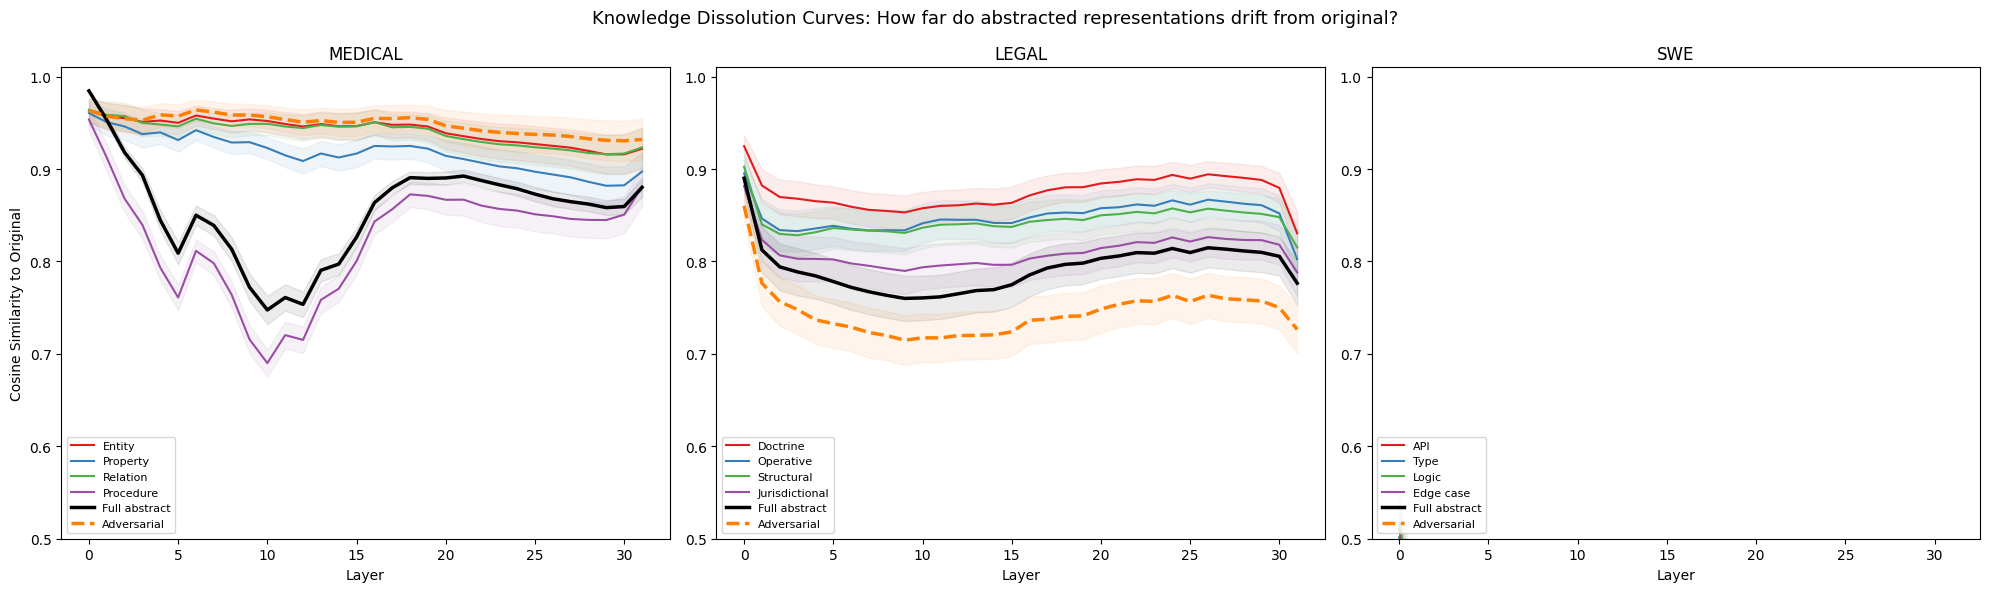

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---- Correct paths ----
PROJECT_ROOT = Path("/Users/brandonlepine/Repositories/Research_Repositories/smi")
DATA_DIR = PROJECT_ROOT / "benchmark_datasets"
SURGICAL_DIR = DATA_DIR / "surgical_abstractions"
RESULTS_DIR = PROJECT_ROOT / "results"
ACTIVATIONS_DIR = RESULTS_DIR / "activations"
PATCHING_DIR = RESULTS_DIR / "patching"
MODEL_PATH = PROJECT_ROOT / "models" / "llama2-7b"

def cosine_sim(a, b):
    a = a.astype(np.float32)
    b = b.astype(np.float32)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

domain_configs = {
    "medical": {
        "singles": ["abstract_entity", "abstract_property", "abstract_relation", "abstract_procedure"],
        "full": "abstract_entity+property+relation+procedure",
        "colors": {"abstract_entity": "#e41a1c", "abstract_property": "#377eb8", 
                   "abstract_relation": "#4daf4a", "abstract_procedure": "#984ea3",
                   "abstract_entity+property+relation+procedure": "#000000",
                   "adversarial": "#ff7f00"},
        "short_names": {"abstract_entity": "Entity", "abstract_property": "Property",
                       "abstract_relation": "Relation", "abstract_procedure": "Procedure",
                       "abstract_entity+property+relation+procedure": "Full abstract",
                       "adversarial": "Adversarial"},
    },
    "legal": {
        "singles": ["abstract_doctrine", "abstract_operative", "abstract_structural", "abstract_jurisdictional"],
        "full": "abstract_doctrine+operative+structural+jurisdictional",
        "colors": {"abstract_doctrine": "#e41a1c", "abstract_operative": "#377eb8",
                   "abstract_structural": "#4daf4a", "abstract_jurisdictional": "#984ea3",
                   "abstract_doctrine+operative+structural+jurisdictional": "#000000",
                   "adversarial": "#ff7f00"},
        "short_names": {"abstract_doctrine": "Doctrine", "abstract_operative": "Operative",
                       "abstract_structural": "Structural", "abstract_jurisdictional": "Jurisdictional",
                       "abstract_doctrine+operative+structural+jurisdictional": "Full abstract",
                       "adversarial": "Adversarial"},
    },
    "swe": {
        "singles": ["abstract_api", "abstract_type", "abstract_logic", "abstract_edgecase"],
        "full": "abstract_api+type+logic+edgecase",
        "colors": {"abstract_api": "#e41a1c", "abstract_type": "#377eb8",
                   "abstract_logic": "#4daf4a", "abstract_edgecase": "#984ea3",
                   "abstract_api+type+logic+edgecase": "#000000",
                   "adversarial": "#ff7f00"},
        "short_names": {"abstract_api": "API", "abstract_type": "Type",
                       "abstract_logic": "Logic", "abstract_edgecase": "Edge case",
                       "abstract_api+type+logic+edgecase": "Full abstract",
                       "adversarial": "Adversarial"},
    },
}

for col, domain in enumerate(["medical", "legal", "swe"]):
    ax = axes[col]
    data = np.load(ACTIVATIONS_DIR / f"{domain}_activations.npz", allow_pickle=True)
    activations = data["activations"]
    cond_names = list(data["condition_names"])
    
    orig_idx = cond_names.index("original")
    config = domain_configs[domain]
    
    plot_conditions = config["singles"] + [config["full"], "adversarial"]
    
    for cond_name in plot_conditions:
        cond_idx = cond_names.index(cond_name)
        
        sims = np.zeros((activations.shape[0], 32))
        for i in range(activations.shape[0]):
            for layer in range(32):
                sims[i, layer] = cosine_sim(
                    activations[i, orig_idx, layer],
                    activations[i, cond_idx, layer]
                )
        
        mean_sim = sims.mean(axis=0)
        sem_sim = sims.std(axis=0) / np.sqrt(sims.shape[0])
        layers = np.arange(32)
        
        color = config["colors"][cond_name]
        label = config["short_names"][cond_name]
        linewidth = 2.5 if cond_name in [config["full"], "adversarial"] else 1.5
        linestyle = "--" if cond_name == "adversarial" else "-"
        
        ax.plot(layers, mean_sim, color=color, linewidth=linewidth, 
                linestyle=linestyle, label=label)
        ax.fill_between(layers, mean_sim - sem_sim, mean_sim + sem_sim, 
                        alpha=0.08, color=color)
    
    ax.set_xlabel("Layer")
    ax.set_title(f"{domain.upper()}")
    ax.legend(fontsize=8, loc="lower left")
    ax.set_ylim(0.5, 1.01)

axes[0].set_ylabel("Cosine Similarity to Original")
fig.suptitle("Knowledge Dissolution Curves: How far do abstracted representations drift from original?",
             fontsize=13)
plt.tight_layout()
plt.savefig(ACTIVATIONS_DIR / "knowledge_dissolution_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
from pathlib import Path

PROJECT_ROOT = Path("/Users/brandonlepine/Repositories/Research_Repositories/smi")
SURGICAL_DIR = PROJECT_ROOT / "benchmark_datasets" / "surgical_abstractions"
ACTIVATIONS_DIR = PROJECT_ROOT / "results" / "activations"

# Check surgical files
print("=== Surgical abstraction files ===")
for f in sorted(SURGICAL_DIR.glob("*")):
    print(f"  {f.name:40s} | {f.stat().st_size / 1024:.0f} KB")

# Check activation files
print("\n=== Activation files ===")
for f in sorted(ACTIVATIONS_DIR.glob("*")):
    print(f"  {f.name:40s} | {f.stat().st_size / 1e6:.0f} MB")

# Check if swe surgical has any content
swe_surgical = SURGICAL_DIR / "swe_surgical.jsonl"
if swe_surgical.exists():
    import json
    from collections import Counter
    counts = Counter()
    total = 0
    with open(swe_surgical) as f:
        for line in f:
            rec = json.loads(line)
            total += 1
            if rec["success"]:
                counts[rec["category"]] += 1
    print(f"\n=== SWE surgical: {total} total records ===")
    for cat, n in sorted(counts.items()):
        print(f"  {cat}: {n}")
else:
    print("\n⚠️  swe_surgical.jsonl does not exist!")

# Check composed
swe_composed = SURGICAL_DIR / "swe_composed.jsonl"
if swe_composed.exists():
    with open(swe_composed) as f:
        lines = f.readlines()
    print(f"\nswe_composed.jsonl: {len(lines)} lines")
else:
    print("\n⚠️  swe_composed.jsonl does not exist!")

=== Surgical abstraction files ===
  legal_composed.jsonl                     | 1512 KB
  legal_surgical.jsonl                     | 588 KB
  medical_composed.jsonl                   | 688 KB
  medical_surgical.jsonl                   | 362 KB
  swe_composed.jsonl                       | 773 KB
  swe_surgical.jsonl                       | 287 KB

=== Activation files ===
  knowledge_dissolution_curves.png         | 0 MB
  legal_activations.npz                    | 605 MB
  medical_activations.npz                  | 246 MB
  swe_activations.npz                      | 247 MB

=== SWE surgical: 240 total records ===
  api: 60
  edgecase: 60
  logic: 60
  type: 60

swe_composed.jsonl: 660 lines


In [19]:
# Quick test — can we load and index SWE correctly?
data = np.load(ACTIVATIONS_DIR / "swe_activations.npz", allow_pickle=True)
cond_names = list(data["condition_names"])
print("SWE conditions:", cond_names)
print("'original' at index:", cond_names.index("original"))
print("'abstract_api' at index:", cond_names.index("abstract_api"))
print("'abstract_api+type+logic+edgecase' at index:", cond_names.index("abstract_api+type+logic+edgecase"))
print("Shape:", data["activations"].shape)

SWE conditions: [np.str_('abstract_api'), np.str_('abstract_api+edgecase'), np.str_('abstract_api+logic'), np.str_('abstract_api+logic+edgecase'), np.str_('abstract_api+type'), np.str_('abstract_api+type+edgecase'), np.str_('abstract_api+type+logic'), np.str_('abstract_api+type+logic+edgecase'), np.str_('abstract_edgecase'), np.str_('abstract_logic'), np.str_('abstract_logic+edgecase'), np.str_('abstract_type'), np.str_('abstract_type+edgecase'), np.str_('abstract_type+logic'), np.str_('abstract_type+logic+edgecase'), np.str_('adversarial'), np.str_('original')]
'original' at index: 16
'abstract_api' at index: 0
'abstract_api+type+logic+edgecase' at index: 7
Shape: (60, 17, 32, 4096)


In [21]:
data = np.load(ACTIVATIONS_DIR / "swe_activations.npz", allow_pickle=True)
cond_names = list(data["condition_names"])
print("SWE conditions:", cond_names)
print("'abstract_api+type+logic+edgecase' at index:", cond_names.index("abstract_api+type+logic+edgecase"))

SWE conditions: [np.str_('abstract_api'), np.str_('abstract_api+edgecase'), np.str_('abstract_api+logic'), np.str_('abstract_api+logic+edgecase'), np.str_('abstract_api+type'), np.str_('abstract_api+type+edgecase'), np.str_('abstract_api+type+logic'), np.str_('abstract_api+type+logic+edgecase'), np.str_('abstract_edgecase'), np.str_('abstract_logic'), np.str_('abstract_logic+edgecase'), np.str_('abstract_type'), np.str_('abstract_type+edgecase'), np.str_('abstract_type+logic'), np.str_('abstract_type+logic+edgecase'), np.str_('adversarial'), np.str_('original')]
'abstract_api+type+logic+edgecase' at index: 7


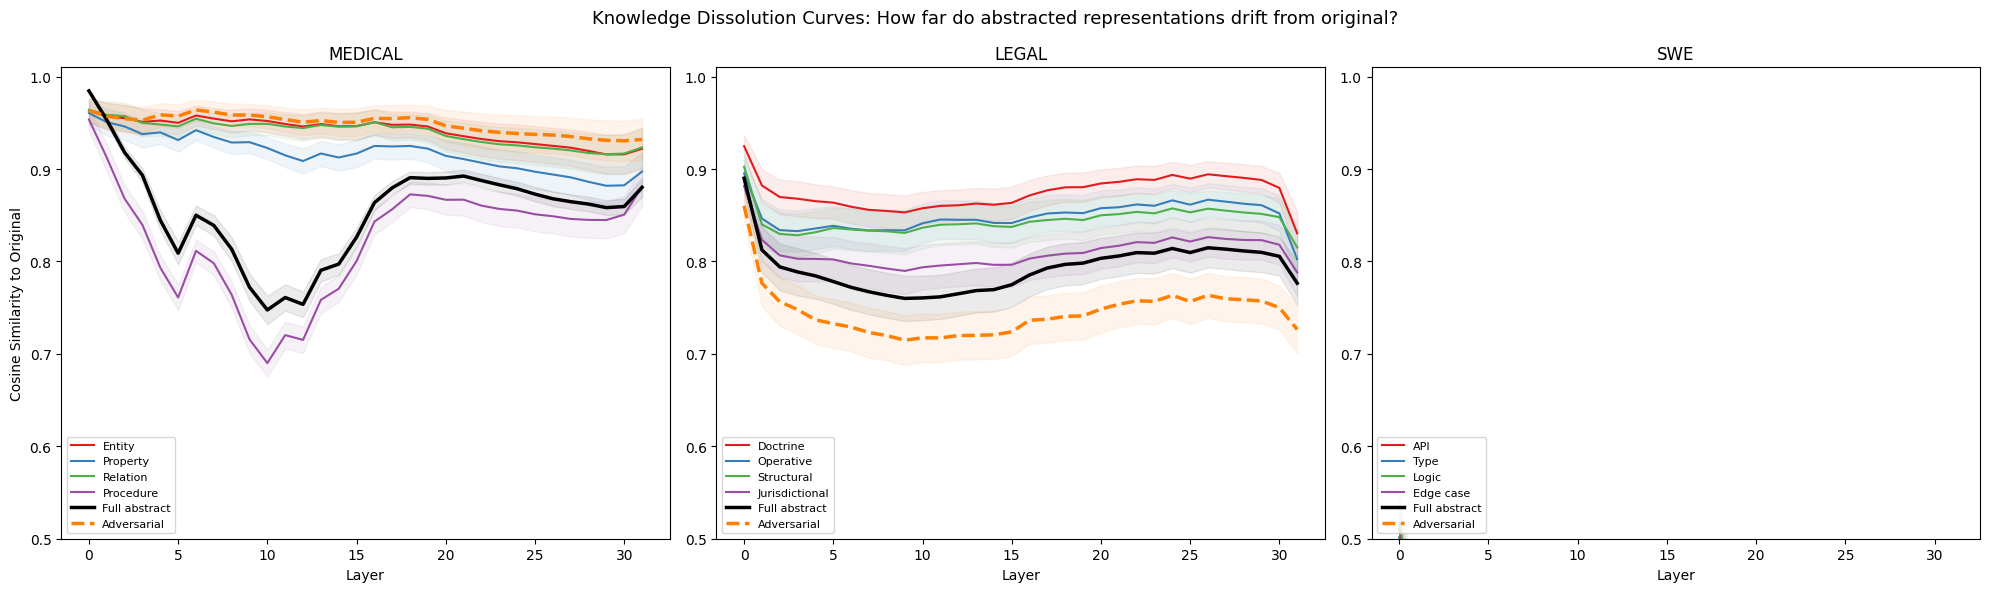

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for col, domain in enumerate(["medical", "legal", "swe"]):
    ax = axes[col]
    data = np.load(ACTIVATIONS_DIR / f"{domain}_activations.npz", allow_pickle=True)
    activations = data["activations"]
    cond_names = [str(c) for c in data["condition_names"]]  # force plain strings
    
    orig_idx = cond_names.index("original")
    config = domain_configs[domain]
    
    plot_conditions = config["singles"] + [config["full"], "adversarial"]
    
    for cond_name in plot_conditions:
        cond_idx = cond_names.index(cond_name)
        
        sims = np.zeros((activations.shape[0], 32))
        for i in range(activations.shape[0]):
            for layer in range(32):
                sims[i, layer] = cosine_sim(
                    activations[i, orig_idx, layer],
                    activations[i, cond_idx, layer]
                )
        
        mean_sim = sims.mean(axis=0)
        sem_sim = sims.std(axis=0) / np.sqrt(sims.shape[0])
        layers = np.arange(32)
        
        color = config["colors"][cond_name]
        label = config["short_names"][cond_name]
        linewidth = 2.5 if cond_name in [config["full"], "adversarial"] else 1.5
        linestyle = "--" if cond_name == "adversarial" else "-"
        
        ax.plot(layers, mean_sim, color=color, linewidth=linewidth, 
                linestyle=linestyle, label=label)
        ax.fill_between(layers, mean_sim - sem_sim, mean_sim + sem_sim, 
                        alpha=0.08, color=color)
    
    ax.set_xlabel("Layer")
    ax.set_title(f"{domain.upper()}")
    ax.legend(fontsize=8, loc="lower left")
    ax.set_ylim(0.5, 1.01)

axes[0].set_ylabel("Cosine Similarity to Original")
fig.suptitle("Knowledge Dissolution Curves: How far do abstracted representations drift from original?",
             fontsize=13)
plt.tight_layout()
plt.savefig(ACTIVATIONS_DIR / "knowledge_dissolution_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# Check if SWE abstractions actually changed anything
import json

swe_surgical = PROJECT_ROOT / "benchmark_datasets" / "surgical_abstractions" / "swe_surgical.jsonl"
from collections import Counter

empty_counts = Counter()
replacement_counts = Counter()

with open(swe_surgical) as f:
    for line in f:
        rec = json.loads(line)
        if rec["success"]:
            n_repl = len(rec["result"].get("replacements", []))
            replacement_counts[rec["category"]] += n_repl
            if n_repl == 0:
                empty_counts[rec["category"]] += 1

print("=== Replacements per category (total) ===")
for cat in sorted(replacement_counts):
    print(f"  {cat:15s} | {replacement_counts[cat]} replacements | {empty_counts.get(cat, 0)} items with 0 replacements")

# Also check: are the modified texts actually different from originals?
import pandas as pd
originals = pd.read_parquet(DATA_DIR / "swe" / "swe_sample.parquet")

data = np.load(ACTIVATIONS_DIR / "swe_activations.npz", allow_pickle=True)
activations = data["activations"]
cond_names = [str(c) for c in data["condition_names"]]
orig_idx = cond_names.index("original")
api_idx = cond_names.index("abstract_api")

# Check cosine sim at a few layers for a few items
print("\n=== SWE cosine sim spot check ===")
for item in range(min(5, activations.shape[0])):
    for layer in [0, 15, 31]:
        sim = cosine_sim(activations[item, orig_idx, layer], activations[item, api_idx, layer])
        print(f"  item {item} | layer {layer:2d} | original vs abstract_api: {sim:.6f}")

=== Replacements per category (total) ===
  api             | 167 replacements | 33 items with 0 replacements
  edgecase        | 29 replacements | 40 items with 0 replacements
  logic           | 47 replacements | 33 items with 0 replacements
  type            | 65 replacements | 30 items with 0 replacements

=== SWE cosine sim spot check ===
  item 0 | layer  0 | original vs abstract_api: 0.362607
  item 0 | layer 15 | original vs abstract_api: 0.307691
  item 0 | layer 31 | original vs abstract_api: 0.648775
  item 1 | layer  0 | original vs abstract_api: 0.363306
  item 1 | layer 15 | original vs abstract_api: 0.559939
  item 1 | layer 31 | original vs abstract_api: 0.746203
  item 2 | layer  0 | original vs abstract_api: 0.384791
  item 2 | layer 15 | original vs abstract_api: 0.094443
  item 2 | layer 31 | original vs abstract_api: 0.251840
  item 3 | layer  0 | original vs abstract_api: 0.393267
  item 3 | layer 15 | original vs abstract_api: 0.117926
  item 3 | layer 31 | origi

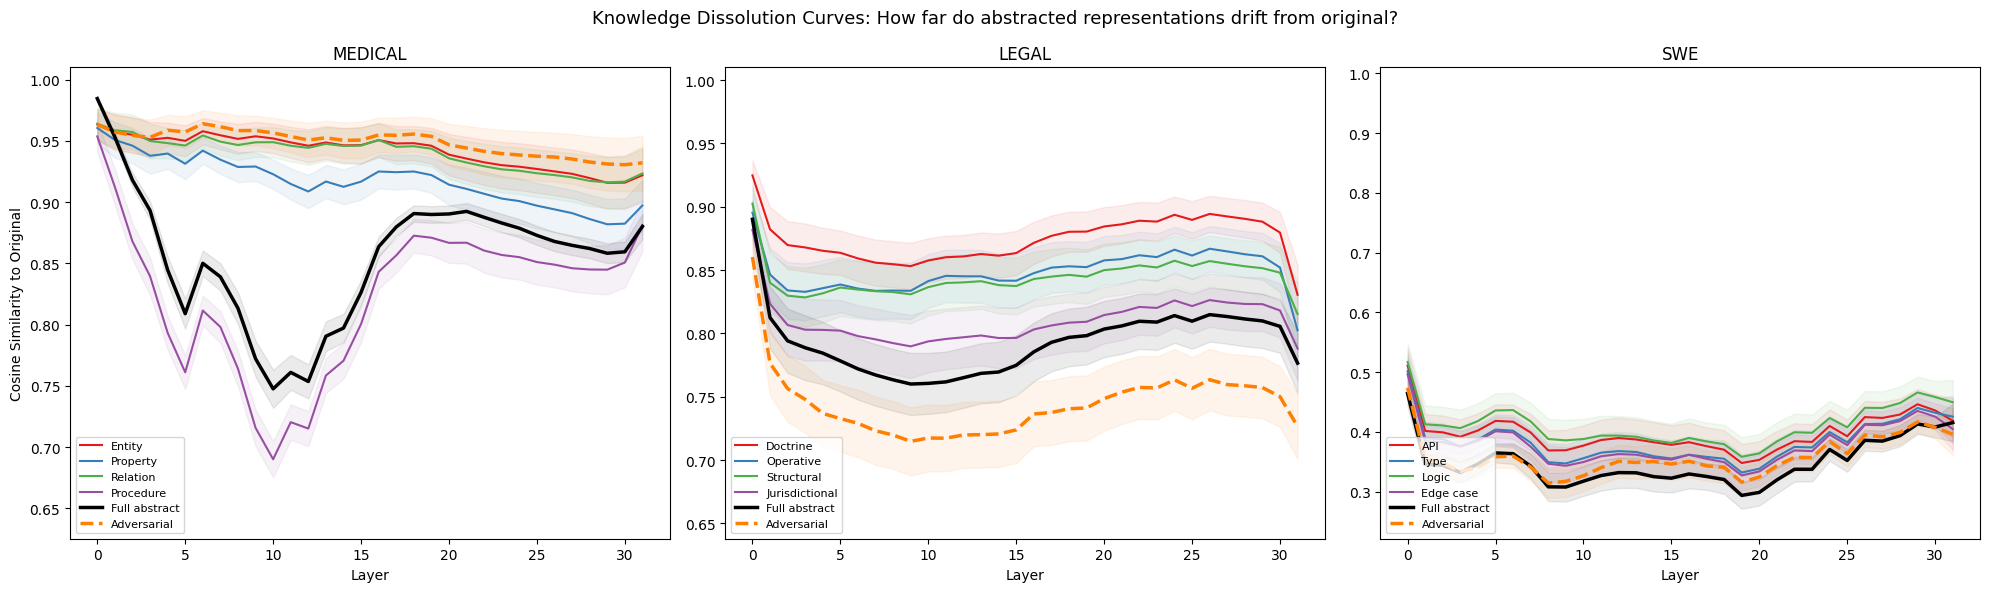

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for col, domain in enumerate(["medical", "legal", "swe"]):
    ax = axes[col]
    data = np.load(ACTIVATIONS_DIR / f"{domain}_activations.npz", allow_pickle=True)
    activations = data["activations"]
    cond_names = [str(c) for c in data["condition_names"]]
    
    orig_idx = cond_names.index("original")
    config = domain_configs[domain]
    
    plot_conditions = config["singles"] + [config["full"], "adversarial"]
    
    all_sims_min = 1.0  # track min for dynamic ylim
    
    for cond_name in plot_conditions:
        cond_idx = cond_names.index(cond_name)
        
        sims = np.zeros((activations.shape[0], 32))
        for i in range(activations.shape[0]):
            for layer in range(32):
                sims[i, layer] = cosine_sim(
                    activations[i, orig_idx, layer],
                    activations[i, cond_idx, layer]
                )
        
        mean_sim = sims.mean(axis=0)
        sem_sim = sims.std(axis=0) / np.sqrt(sims.shape[0])
        layers = np.arange(32)
        
        all_sims_min = min(all_sims_min, (mean_sim - sem_sim).min())
        
        color = config["colors"][cond_name]
        label = config["short_names"][cond_name]
        linewidth = 2.5 if cond_name in [config["full"], "adversarial"] else 1.5
        linestyle = "--" if cond_name == "adversarial" else "-"
        
        ax.plot(layers, mean_sim, color=color, linewidth=linewidth, 
                linestyle=linestyle, label=label)
        ax.fill_between(layers, mean_sim - sem_sim, mean_sim + sem_sim, 
                        alpha=0.08, color=color)
    
    ax.set_xlabel("Layer")
    ax.set_title(f"{domain.upper()}")
    ax.legend(fontsize=8, loc="lower left")
    # Dynamic y-axis based on actual data range
    ax.set_ylim(max(0.0, all_sims_min - 0.05), 1.01)

axes[0].set_ylabel("Cosine Similarity to Original")
fig.suptitle("Knowledge Dissolution Curves: How far do abstracted representations drift from original?",
             fontsize=13)
plt.tight_layout()
plt.savefig(ACTIVATIONS_DIR / "knowledge_dissolution_curves.png", dpi=150, bbox_inches="tight")
plt.show()

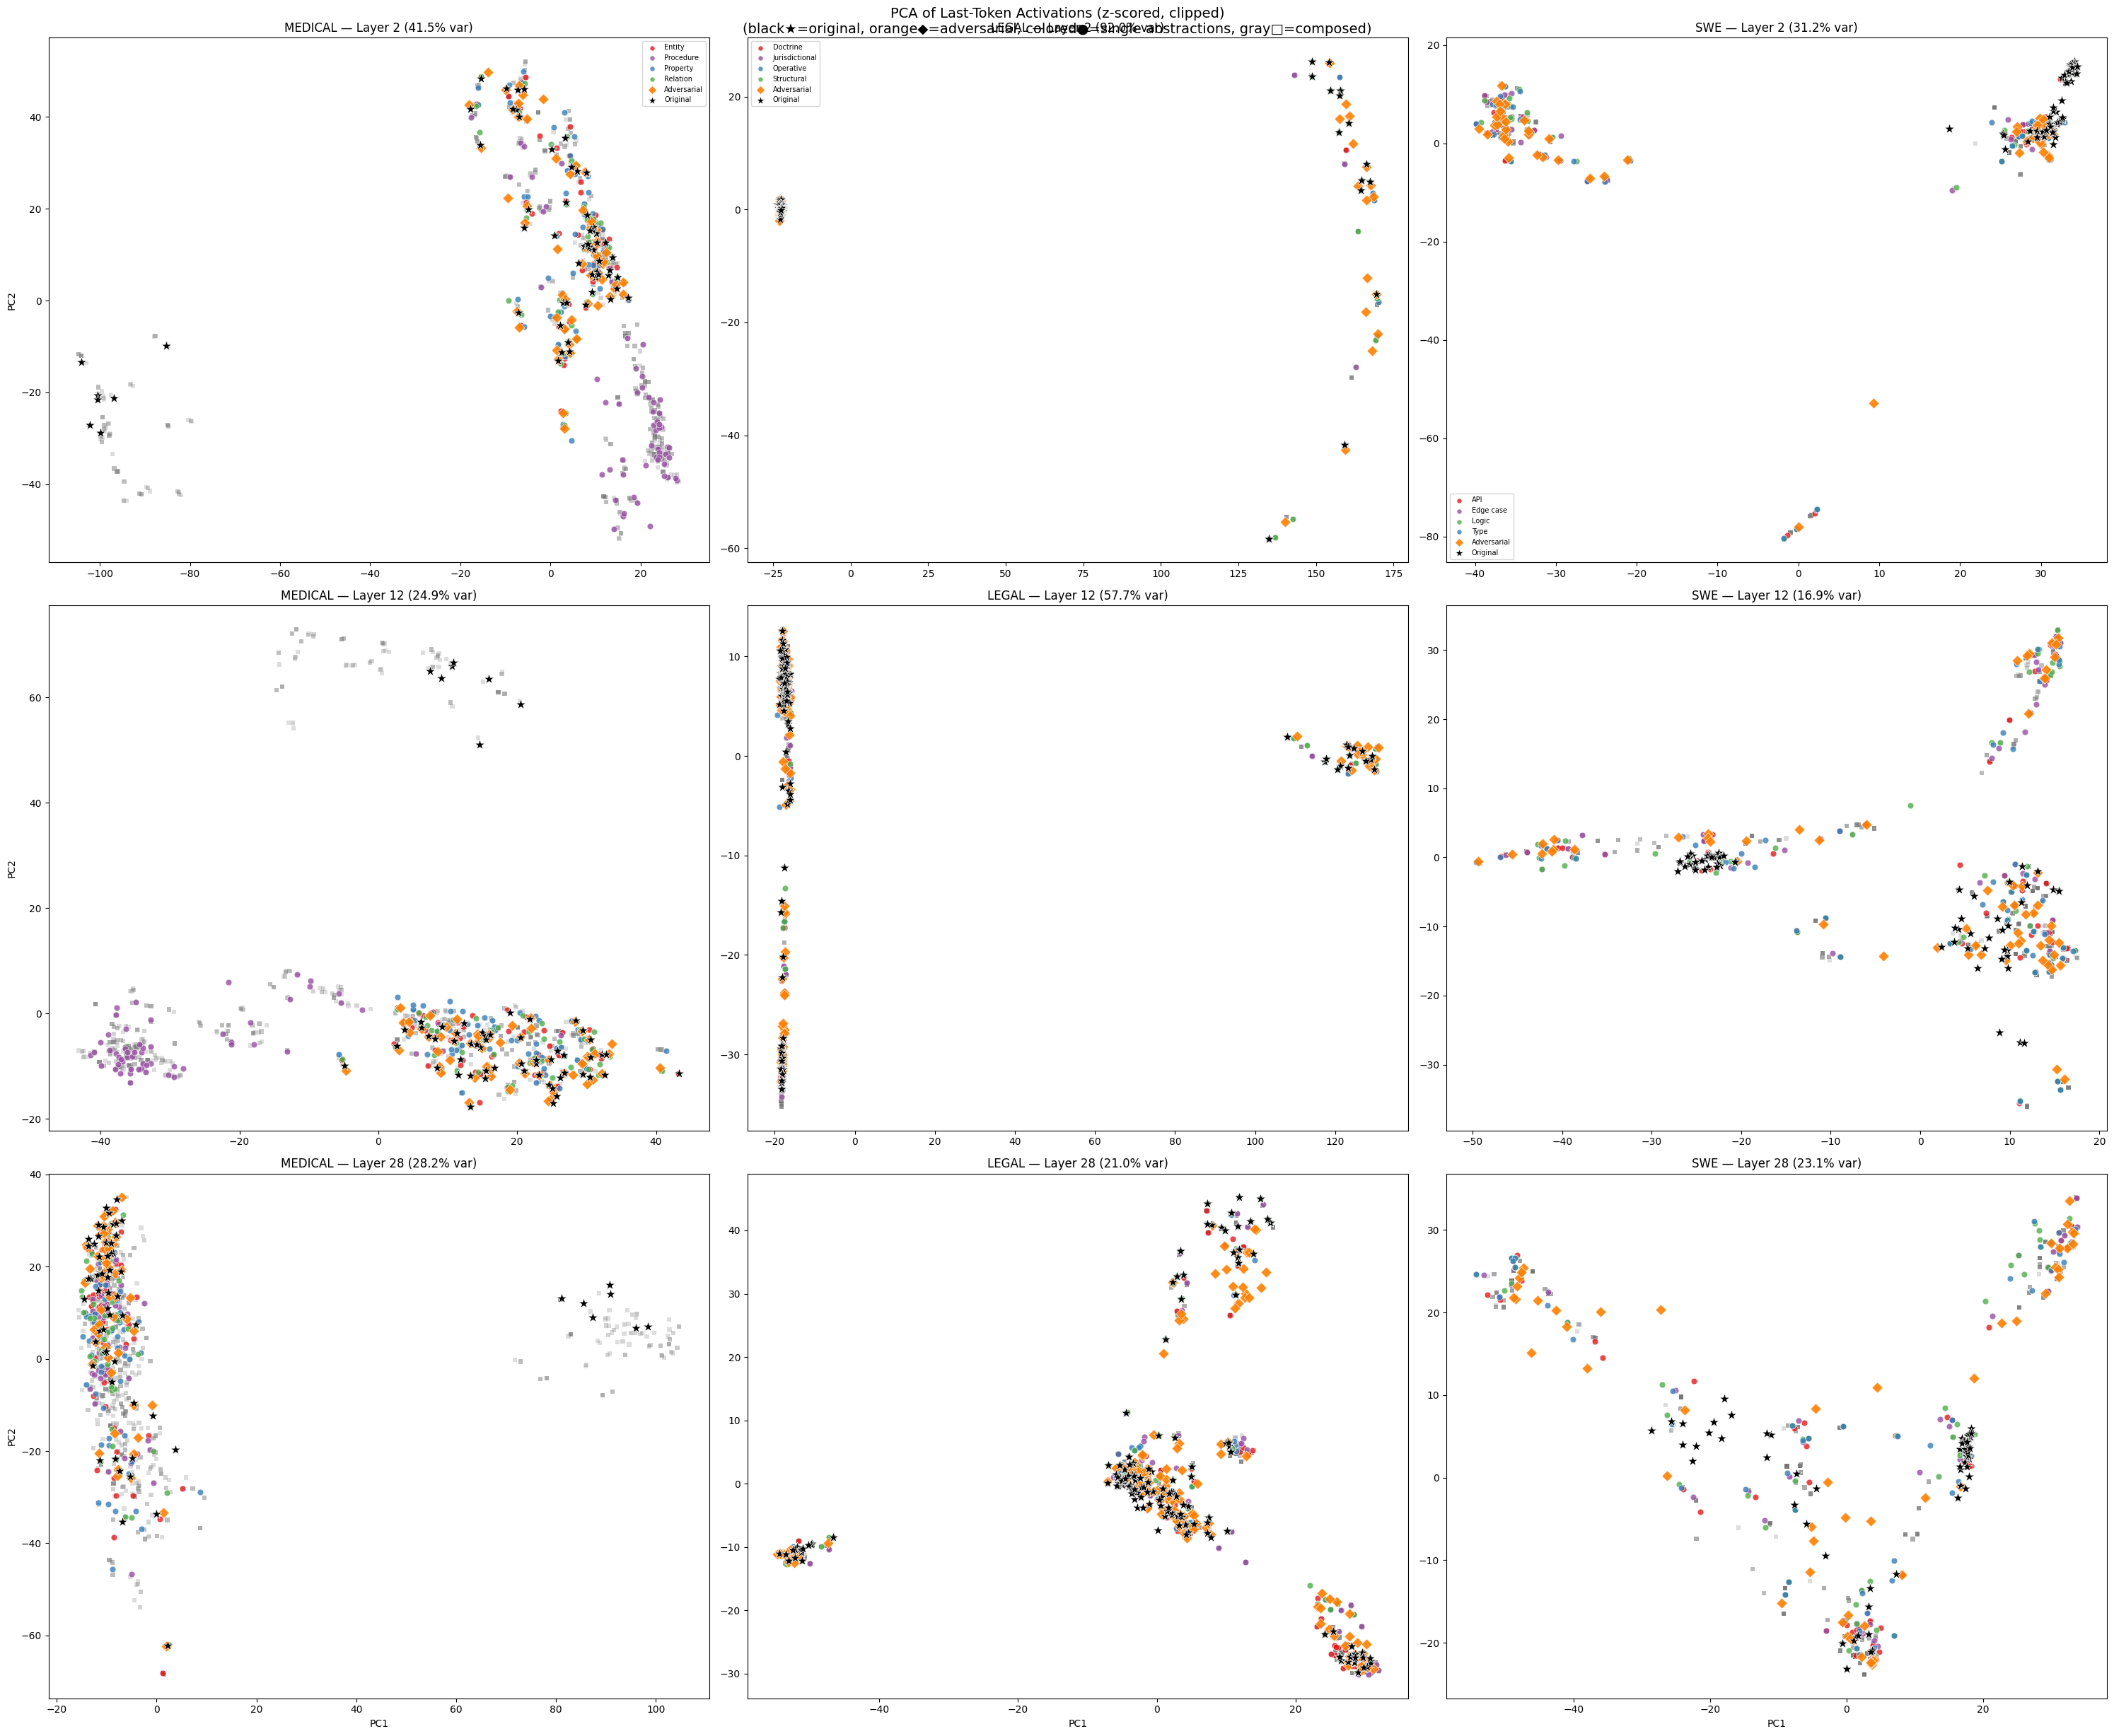

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pathlib import Path

PROJECT_ROOT = Path("/Users/brandonlepine/Repositories/Research_Repositories/smi")
ACTIVATIONS_DIR = PROJECT_ROOT / "results" / "activations"

LAYERS_TO_PLOT = [2, 12, 28]

def get_condition_style(cond_name, domain):
    singles = {
        "medical": {
            "abstract_entity": ("#e41a1c", "o", 40, 0.8, "Entity"),
            "abstract_property": ("#377eb8", "o", 40, 0.8, "Property"),
            "abstract_relation": ("#4daf4a", "o", 40, 0.8, "Relation"),
            "abstract_procedure": ("#984ea3", "o", 40, 0.8, "Procedure"),
        },
        "legal": {
            "abstract_doctrine": ("#e41a1c", "o", 40, 0.8, "Doctrine"),
            "abstract_operative": ("#377eb8", "o", 40, 0.8, "Operative"),
            "abstract_structural": ("#4daf4a", "o", 40, 0.8, "Structural"),
            "abstract_jurisdictional": ("#984ea3", "o", 40, 0.8, "Jurisdictional"),
        },
        "swe": {
            "abstract_api": ("#e41a1c", "o", 40, 0.8, "API"),
            "abstract_type": ("#377eb8", "o", 40, 0.8, "Type"),
            "abstract_logic": ("#4daf4a", "o", 40, 0.8, "Logic"),
            "abstract_edgecase": ("#984ea3", "o", 40, 0.8, "Edge case"),
        },
    }
    if cond_name == "original":
        return ("#000000", "*", 120, 1.0, "Original")
    elif cond_name == "adversarial":
        return ("#ff7f00", "D", 60, 0.9, "Adversarial")
    elif cond_name in singles.get(domain, {}):
        return singles[domain][cond_name]
    elif "+" in cond_name:
        n_cats = cond_name.replace("abstract_", "").count("+") + 1
        gray = max(0.3, 0.8 - n_cats * 0.12)
        return (str(gray), "s", 20, 0.3, None)
    else:
        return ("#999999", "s", 20, 0.3, None)


fig, axes = plt.subplots(3, 3, figsize=(30, 25))

for col, domain in enumerate(["medical", "legal", "swe"]):
    data = np.load(ACTIVATIONS_DIR / f"{domain}_activations.npz", allow_pickle=True)
    activations = data["activations"]
    cond_names = [str(c) for c in data["condition_names"]]
    n_items = activations.shape[0]
    n_conds = activations.shape[1]

    for row, layer in enumerate(LAYERS_TO_PLOT):
        ax = axes[row, col]

        flat = activations[:, :, layer, :].reshape(-1, 4096).astype(np.float32)
        cond_labels = np.array([cond_names[j] for i in range(n_items) for j in range(n_conds)])

        # Remove zero rows
        nonzero_mask = np.abs(flat).sum(axis=1) > 0
        flat_clean = flat[nonzero_mask]
        labels_clean = cond_labels[nonzero_mask]

        # Z-score normalize to prevent outlier domination
        scaler = StandardScaler()
        flat_normed = scaler.fit_transform(flat_clean)

        # Clip extreme values (beyond 3 std)
        flat_normed = np.clip(flat_normed, -3, 3)

        pca = PCA(n_components=2)
        coords = pca.fit_transform(flat_normed)

        # Plot composed (background) first
        for cond_name in cond_names:
            color, marker, size, alpha, label = get_condition_style(cond_name, domain)
            if label is not None:
                continue
            mask = labels_clean == cond_name
            if mask.sum() == 0:
                continue
            ax.scatter(coords[mask, 0], coords[mask, 1], c=color, marker=marker,
                       s=size, alpha=alpha, edgecolors="none")

        # Then singles + original + adversarial on top
        for cond_name in cond_names:
            color, marker, size, alpha, label = get_condition_style(cond_name, domain)
            if label is None:
                continue
            mask = labels_clean == cond_name
            if mask.sum() == 0:
                continue
            ax.scatter(coords[mask, 0], coords[mask, 1], c=color, marker=marker,
                       s=size, alpha=alpha, edgecolors="white", linewidths=0.5,
                       label=label)

        var_explained = pca.explained_variance_ratio_[:2].sum() * 100
        ax.set_title(f"{domain.upper()} — Layer {layer} ({var_explained:.1f}% var)")
        if row == 2:
            ax.set_xlabel("PC1")
        if col == 0:
            ax.set_ylabel("PC2")
        if row == 0:
            ax.legend(fontsize=7, loc="best", markerscale=0.8)

fig.suptitle("PCA of Last-Token Activations (z-scored, clipped)\n"
             "(black★=original, orange◆=adversarial, colored●=single abstractions, gray□=composed)",
             fontsize=14)
plt.tight_layout()
plt.savefig(ACTIVATIONS_DIR / "pca_conditions_normalized.png", dpi=150, bbox_inches="tight")
plt.show()

/Users/brandonlepine/Repositories/Research_Repositories/smi/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/brandonlepine/Repositories/Research_Repositories/smi/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/brandonlepine/Repositories/Research_Repositories/smi/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/brandonlepine/Repositories/Research_Repositories/smi/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/brandonlepine/Repositories/Research_Repositories/smi/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: U

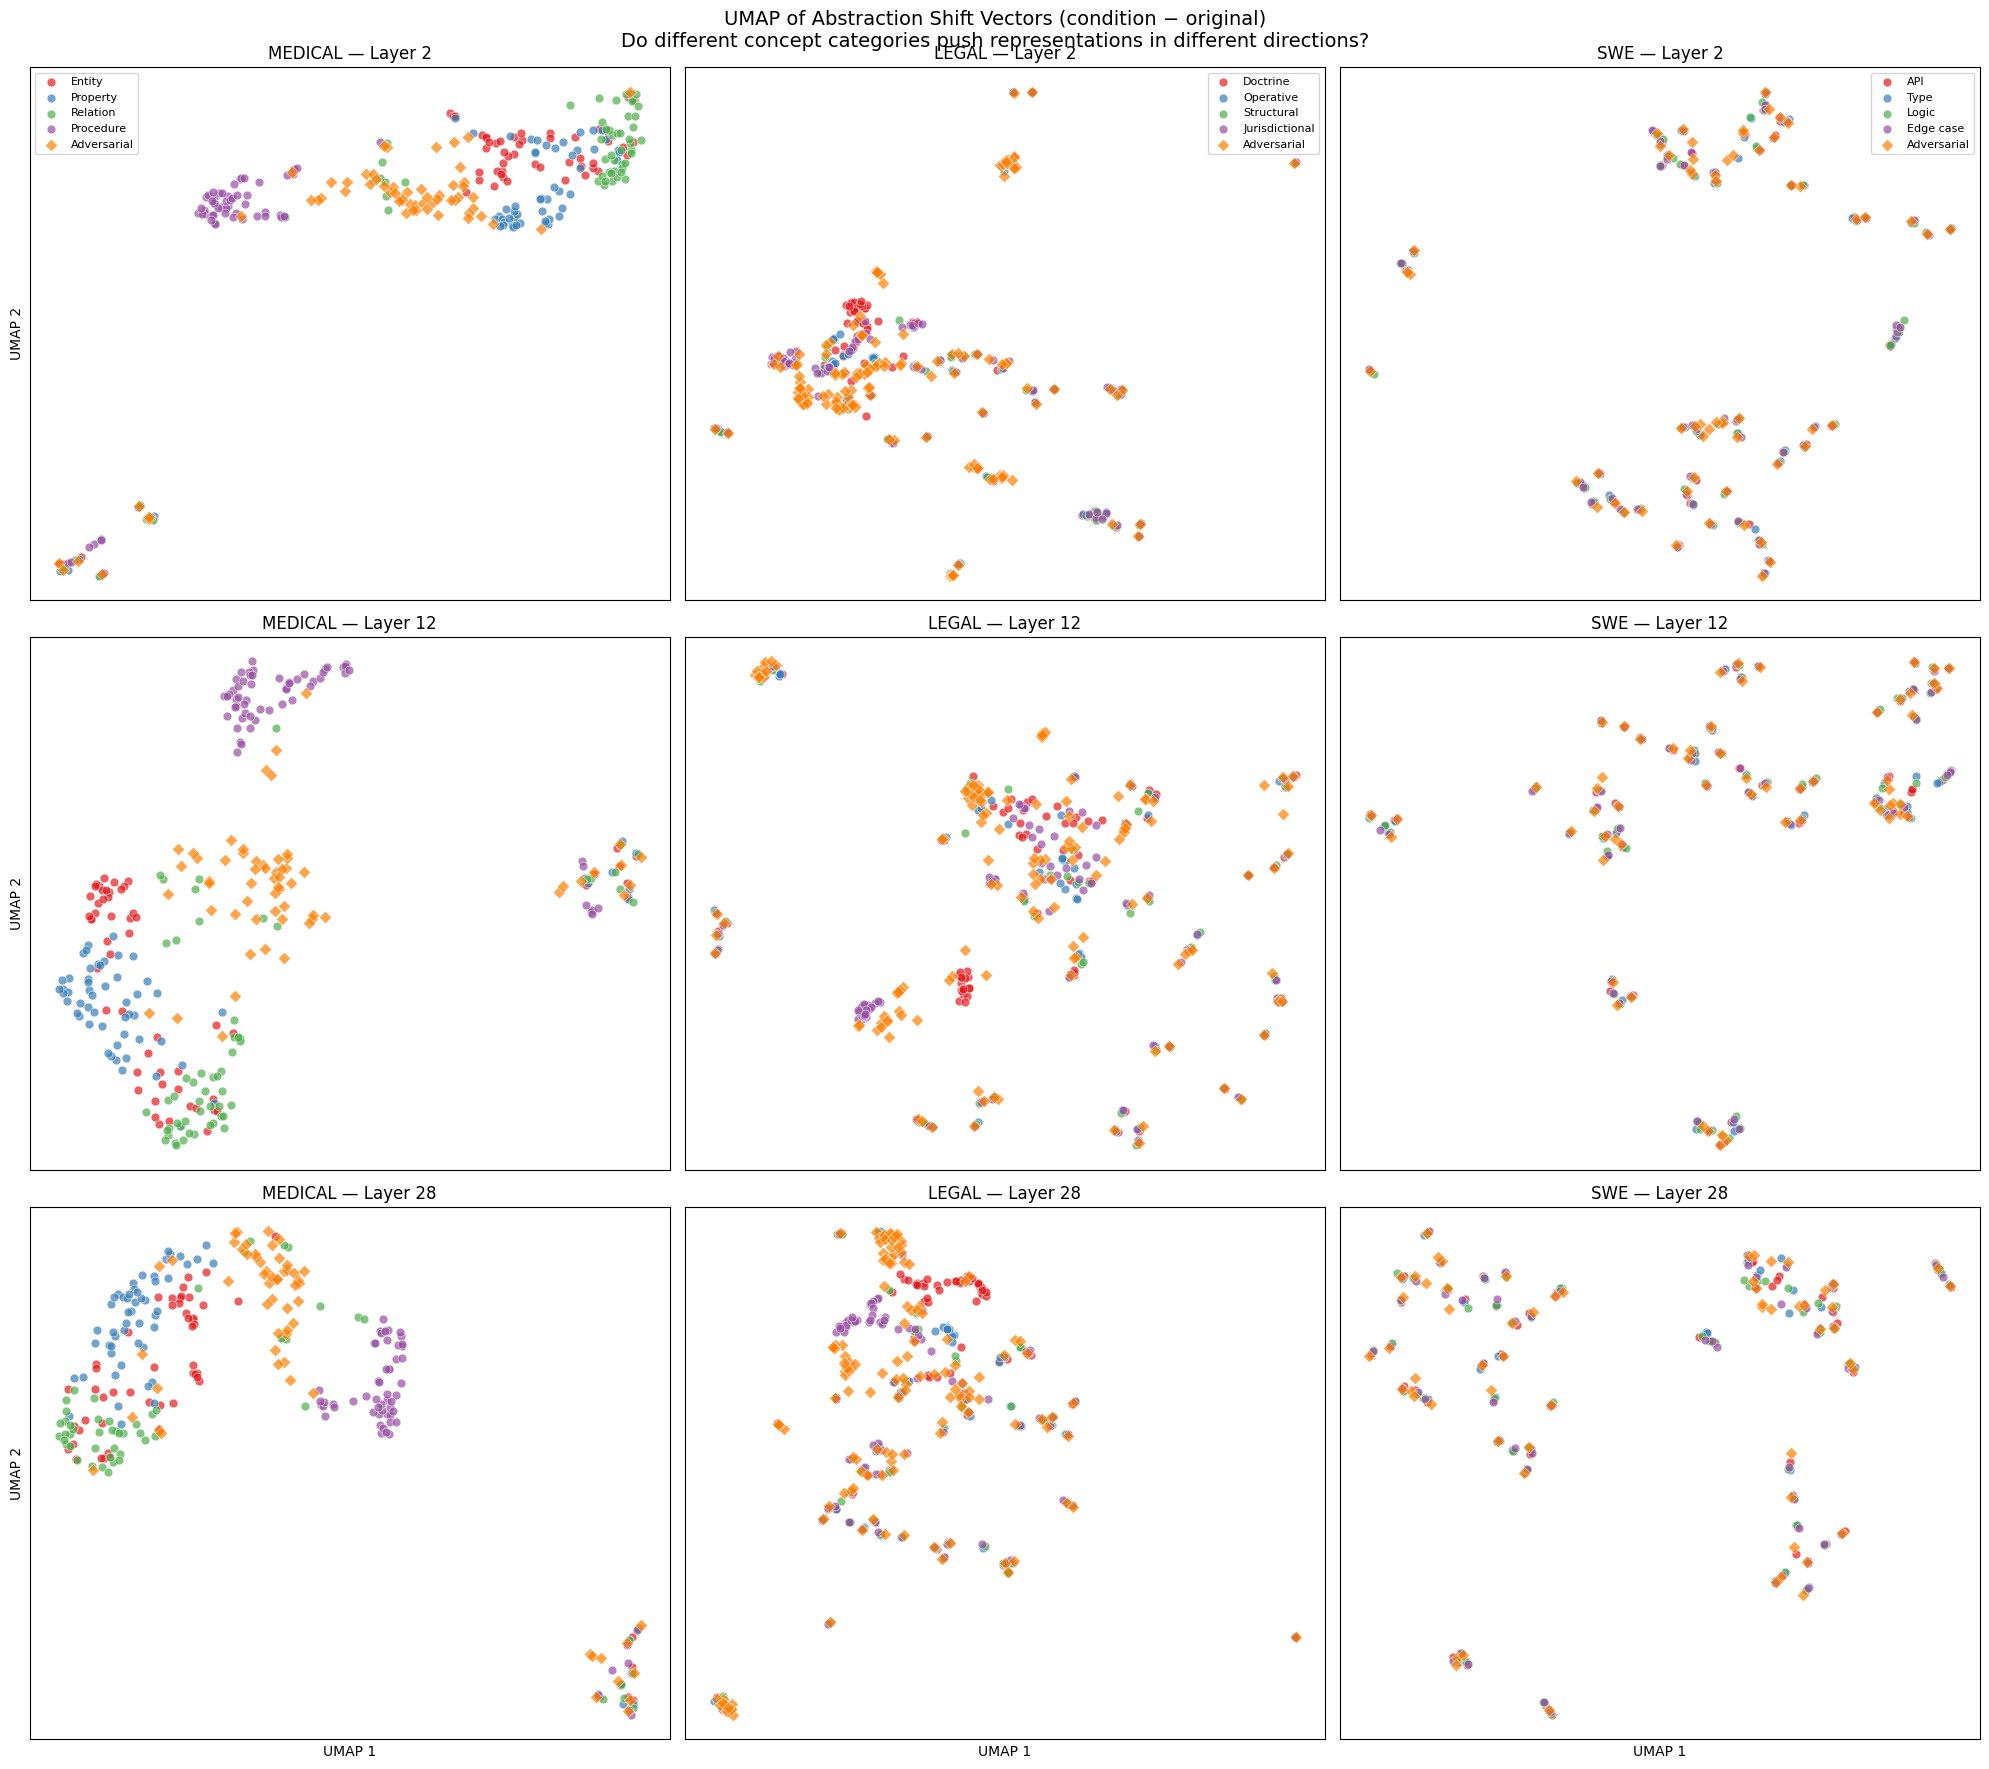

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from pathlib import Path

PROJECT_ROOT = Path("/Users/brandonlepine/Repositories/Research_Repositories/smi")
ACTIVATIONS_DIR = PROJECT_ROOT / "results" / "activations"

LAYERS_TO_PLOT = [2, 12, 28]

# Simpler style - just the conditions we care about
CONDITION_STYLES = {
    "medical": {
        "abstract_entity":    ("#e41a1c", "Entity"),
        "abstract_property":  ("#377eb8", "Property"),
        "abstract_relation":  ("#4daf4a", "Relation"),
        "abstract_procedure": ("#984ea3", "Procedure"),
        "adversarial":        ("#ff7f00", "Adversarial"),
    },
    "legal": {
        "abstract_doctrine":      ("#e41a1c", "Doctrine"),
        "abstract_operative":     ("#377eb8", "Operative"),
        "abstract_structural":    ("#4daf4a", "Structural"),
        "abstract_jurisdictional":("#984ea3", "Jurisdictional"),
        "adversarial":            ("#ff7f00", "Adversarial"),
    },
    "swe": {
        "abstract_api":      ("#e41a1c", "API"),
        "abstract_type":     ("#377eb8", "Type"),
        "abstract_logic":    ("#4daf4a", "Logic"),
        "abstract_edgecase": ("#984ea3", "Edge case"),
        "adversarial":       ("#ff7f00", "Adversarial"),
    },
}

fig, axes = plt.subplots(3, 3, figsize=(20, 18))

for col, domain in enumerate(["medical", "legal", "swe"]):
    data = np.load(ACTIVATIONS_DIR / f"{domain}_activations.npz", allow_pickle=True)
    activations = data["activations"].astype(np.float32)
    cond_names = [str(c) for c in data["condition_names"]]
    orig_idx = cond_names.index("original")
    n_items = activations.shape[0]
    styles = CONDITION_STYLES[domain]

    for row, layer in enumerate(LAYERS_TO_PLOT):
        ax = axes[row, col]
        
        # Compute shift vectors: condition - original for each item
        shift_vectors = []
        shift_labels = []
        
        for cond_name in styles.keys():
            cond_idx = cond_names.index(cond_name)
            for i in range(n_items):
                orig_act = activations[i, orig_idx, layer, :]
                cond_act = activations[i, cond_idx, layer, :]
                shift = cond_act - orig_act
                # Skip if zero (missing data)
                if np.abs(shift).sum() > 0:
                    shift_vectors.append(shift)
                    shift_labels.append(cond_name)
        
        shift_matrix = np.array(shift_vectors)
        shift_labels = np.array(shift_labels)
        
        # Add jitter
        rng = np.random.RandomState(42)
        shift_matrix += rng.normal(0, 1e-4, shift_matrix.shape).astype(np.float32)
        
        # UMAP on shift vectors
        reducer = umap.UMAP(
            n_components=2, n_neighbors=15, min_dist=0.1,
            metric="cosine", init="random", random_state=42,
        )
        coords = reducer.fit_transform(shift_matrix)
        
        # Plot each condition
        for cond_name, (color, label) in styles.items():
            mask = shift_labels == cond_name
            if mask.sum() == 0:
                continue
            marker = "D" if cond_name == "adversarial" else "o"
            ax.scatter(coords[mask, 0], coords[mask, 1], c=color, marker=marker,
                       s=40, alpha=0.7, edgecolors="white", linewidths=0.5,
                       label=label)
        
        ax.set_title(f"{domain.upper()} — Layer {layer}")
        if row == 2:
            ax.set_xlabel("UMAP 1")
        if col == 0:
            ax.set_ylabel("UMAP 2")
        if row == 0:
            ax.legend(fontsize=8, loc="best")
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle("UMAP of Abstraction Shift Vectors (condition − original)\n"
             "Do different concept categories push representations in different directions?",
             fontsize=14)
plt.tight_layout()
plt.savefig(ACTIVATIONS_DIR / "umap_shift_vectors.png", dpi=150, bbox_inches="tight")
plt.show()

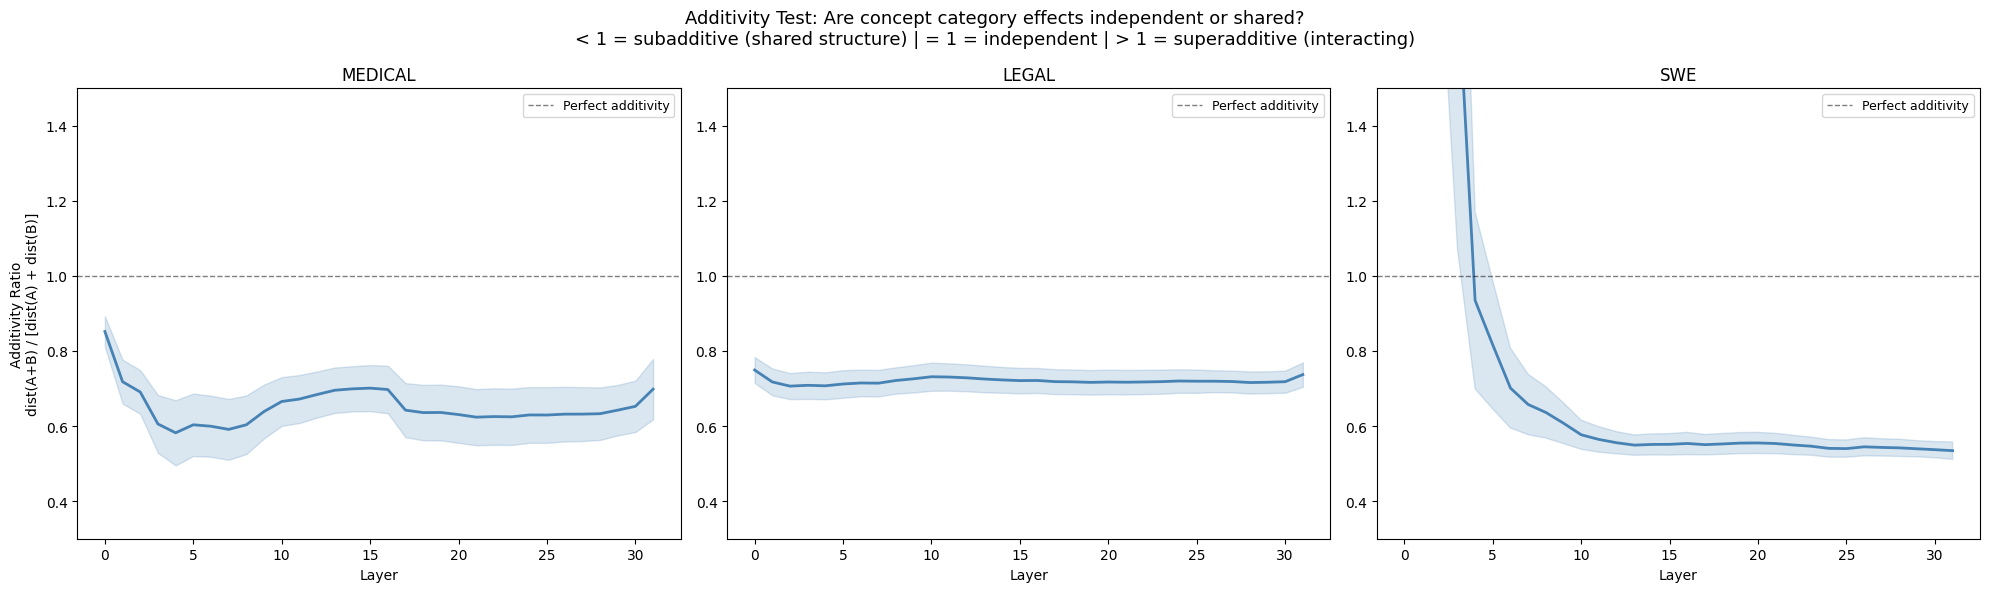


=== Additivity ratios at peak dissolution layer (L12) ===

--- MEDICAL ---
  entity          + property        | ratio = 0.627 | subadditive (shared)
  entity          + relation        | ratio = 0.416 | subadditive (shared)
  entity          + procedure       | ratio = 0.835 | subadditive (shared)
  property        + relation        | ratio = 0.615 | subadditive (shared)
  property        + procedure       | ratio = 0.849 | subadditive (shared)
  relation        + procedure       | ratio = 0.762 | subadditive (shared)

--- LEGAL ---
  doctrine        + operative       | ratio = 0.793 | subadditive (shared)
  doctrine        + structural      | ratio = 0.756 | subadditive (shared)
  doctrine        + jurisdictional  | ratio = 0.778 | subadditive (shared)
  operative       + structural      | ratio = 0.534 | subadditive (shared)
  operative       + jurisdictional  | ratio = 0.757 | subadditive (shared)
  structural      + jurisdictional  | ratio = 0.753 | subadditive (shared)

--- SWE 

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path("/Users/brandonlepine/Repositories/Research_Repositories/smi")
ACTIVATIONS_DIR = PROJECT_ROOT / "results" / "activations"

def cosine_sim(a, b):
    a, b = a.astype(np.float32), b.astype(np.float32)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

def cosine_dist(a, b):
    return 1.0 - cosine_sim(a, b)

# Test: is dist(orig, A+B) ≈ dist(orig, A) + dist(orig, B)?
# If yes → categories are independent (additive)
# If dist(A+B) < sum → categories share representational structure (subadditive)
# If dist(A+B) > sum → categories interact/amplify (superadditive)

domain_pairs = {
    "medical": [
        ("abstract_entity", "abstract_property", "abstract_entity+property"),
        ("abstract_entity", "abstract_relation", "abstract_entity+relation"),
        ("abstract_entity", "abstract_procedure", "abstract_entity+procedure"),
        ("abstract_property", "abstract_relation", "abstract_property+relation"),
        ("abstract_property", "abstract_procedure", "abstract_property+procedure"),
        ("abstract_relation", "abstract_procedure", "abstract_relation+procedure"),
    ],
    "legal": [
        ("abstract_doctrine", "abstract_operative", "abstract_doctrine+operative"),
        ("abstract_doctrine", "abstract_structural", "abstract_doctrine+structural"),
        ("abstract_doctrine", "abstract_jurisdictional", "abstract_doctrine+jurisdictional"),
        ("abstract_operative", "abstract_structural", "abstract_operative+structural"),
        ("abstract_operative", "abstract_jurisdictional", "abstract_operative+jurisdictional"),
        ("abstract_structural", "abstract_jurisdictional", "abstract_structural+jurisdictional"),
    ],
    "swe": [
        ("abstract_api", "abstract_type", "abstract_api+type"),
        ("abstract_api", "abstract_logic", "abstract_api+logic"),
        ("abstract_api", "abstract_edgecase", "abstract_api+edgecase"),
        ("abstract_type", "abstract_logic", "abstract_type+logic"),
        ("abstract_type", "abstract_edgecase", "abstract_type+edgecase"),
        ("abstract_logic", "abstract_edgecase", "abstract_logic+edgecase"),
    ],
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for col, domain in enumerate(["medical", "legal", "swe"]):
    ax = axes[col]
    data = np.load(ACTIVATIONS_DIR / f"{domain}_activations.npz", allow_pickle=True)
    activations = data["activations"].astype(np.float32)
    cond_names = [str(c) for c in data["condition_names"]]
    orig_idx = cond_names.index("original")
    n_items = activations.shape[0]
    
    pairs = domain_pairs[domain]
    
    # For each layer, compute mean additivity ratio across all pairs and items
    # Ratio = dist(orig, A+B) / (dist(orig, A) + dist(orig, B))
    # Ratio < 1 → subadditive (shared structure)
    # Ratio = 1 → perfectly additive (independent)
    # Ratio > 1 → superadditive (interacting)
    
    ratios_by_layer = np.zeros((32, len(pairs)))
    
    for p_idx, (cat_a, cat_b, cat_ab) in enumerate(pairs):
        idx_a = cond_names.index(cat_a)
        idx_b = cond_names.index(cat_b)
        idx_ab = cond_names.index(cat_ab)
        
        for layer in range(32):
            item_ratios = []
            for i in range(n_items):
                orig = activations[i, orig_idx, layer]
                dist_a = cosine_dist(orig, activations[i, idx_a, layer])
                dist_b = cosine_dist(orig, activations[i, idx_b, layer])
                dist_ab = cosine_dist(orig, activations[i, idx_ab, layer])
                
                sum_individual = dist_a + dist_b
                if sum_individual > 1e-6:
                    item_ratios.append(dist_ab / sum_individual)
            
            ratios_by_layer[layer, p_idx] = np.mean(item_ratios) if item_ratios else 1.0
    
    # Plot mean ratio ± SEM across pairs
    mean_ratio = ratios_by_layer.mean(axis=1)
    sem_ratio = ratios_by_layer.std(axis=1) / np.sqrt(ratios_by_layer.shape[1])
    layers = np.arange(32)
    
    ax.plot(layers, mean_ratio, color="steelblue", linewidth=2)
    ax.fill_between(layers, mean_ratio - sem_ratio, mean_ratio + sem_ratio,
                     alpha=0.2, color="steelblue")
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.5, label="Perfect additivity")
    ax.set_xlabel("Layer")
    ax.set_title(f"{domain.upper()}")
    ax.set_ylim(0.3, 1.5)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Additivity Ratio\ndist(A+B) / [dist(A) + dist(B)]")
fig.suptitle("Additivity Test: Are concept category effects independent or shared?\n"
             "< 1 = subadditive (shared structure) | = 1 = independent | > 1 = superadditive (interacting)",
             fontsize=13)
plt.tight_layout()
plt.savefig(ACTIVATIONS_DIR / "additivity_test.png", dpi=150, bbox_inches="tight")
plt.show()

# Also break out by pair to see which category combinations are most/least additive
print("\n=== Additivity ratios at peak dissolution layer (L12) ===")
for domain in ["medical", "legal", "swe"]:
    data = np.load(ACTIVATIONS_DIR / f"{domain}_activations.npz", allow_pickle=True)
    activations = data["activations"].astype(np.float32)
    cond_names = [str(c) for c in data["condition_names"]]
    orig_idx = cond_names.index("original")
    n_items = activations.shape[0]
    
    print(f"\n--- {domain.upper()} ---")
    for cat_a, cat_b, cat_ab in domain_pairs[domain]:
        idx_a = cond_names.index(cat_a)
        idx_b = cond_names.index(cat_b)
        idx_ab = cond_names.index(cat_ab)
        
        ratios = []
        for i in range(n_items):
            orig = activations[i, orig_idx, 12]
            da = cosine_dist(orig, activations[i, idx_a, 12])
            db = cosine_dist(orig, activations[i, idx_b, 12])
            dab = cosine_dist(orig, activations[i, idx_ab, 12])
            if da + db > 1e-6:
                ratios.append(dab / (da + db))
        
        short_a = cat_a.replace("abstract_", "")
        short_b = cat_b.replace("abstract_", "")
        r = np.mean(ratios)
        interpretation = "subadditive (shared)" if r < 0.9 else "superadditive (interacting)" if r > 1.1 else "≈ additive"
        print(f"  {short_a:15s} + {short_b:15s} | ratio = {r:.3f} | {interpretation}")

We are going to resample to improve the size of our sample and see if we can get better discrimination here

In [32]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path("/Users/brandonlepine/Repositories/Research_Repositories/smi")
DATA_DIR = PROJECT_ROOT / "benchmark_datasets"

TARGET_TOTAL = 1000
TARGET_PER_DOMAIN = TARGET_TOTAL // 3  # ~333

def stratified_sample(df, col, n_per_stratum, seed=42):
    pieces = []
    for val, group in df.groupby(col):
        pieces.append(group.sample(n=min(n_per_stratum, len(group)), random_state=seed))
    return pd.concat(pieces, ignore_index=True)

# --- Medical: 1273 available, sample ~333 ---
medqa = pd.read_parquet(DATA_DIR / "medical" / "medqa_usmle_test.parquet")
medqa["domain"] = "medical"
medqa["stratum"] = medqa["meta_info"]
medqa["item_text"] = medqa["question"]
# 2 strata, so ~167 each
med_v2 = stratified_sample(medqa, "stratum", 167)
med_v2.to_parquet(DATA_DIR / "medical" / "medqa_sample_v2.parquet", index=False)

# --- Legal: 835 available, sample ~333 ---
legalbench = pd.read_parquet(DATA_DIR / "legal" / "legalbench_full.parquet")
legalbench["domain"] = "legal"
legalbench["item_text"] = legalbench["text"]
# 6 strata, ~56 each (some small strata will be fully included)
legal_v2 = stratified_sample(legalbench, "stratum", 56)
legal_v2.to_parquet(DATA_DIR / "legal" / "legalbench_sample_v2.parquet", index=False)

# --- SWE: 664 available, sample ~333 ---
humaneval = pd.read_parquet(DATA_DIR / "swe" / "humaneval_full.parquet")
swebench = pd.read_parquet(DATA_DIR / "swe" / "swebench_verified_full.parquet")
humaneval["domain"] = "swe"
humaneval["stratum"] = "function_level"
humaneval["item_text"] = humaneval["prompt"]
swebench["domain"] = "swe"
swebench["stratum"] = "repo_level"
swebench["item_text"] = swebench["problem_statement"]
swe_combined = pd.concat([humaneval, swebench], ignore_index=True)
swe_v2 = stratified_sample(swe_combined, "stratum", 167)
swe_v2.to_parquet(DATA_DIR / "swe" / "swe_sample_v2.parquet", index=False)

# --- Summary ---
total = len(med_v2) + len(legal_v2) + len(swe_v2)
print(f"Medical:  {len(med_v2)} items")
for v in sorted(med_v2["stratum"].unique()):
    print(f"  {v}: {(med_v2['stratum']==v).sum()}")

print(f"\nLegal:   {len(legal_v2)} items")
for v in sorted(legal_v2["stratum"].unique()):
    print(f"  {v}: {(legal_v2['stratum']==v).sum()}")

print(f"\nSWE:     {len(swe_v2)} items")
for v in sorted(swe_v2["stratum"].unique()):
    print(f"  {v}: {(swe_v2['stratum']==v).sum()}")

print(f"\nTOTAL:   {total} items")
print(f"API calls: {total * 4} surgical + {total} adversarial = {total * 5}")

Medical:  334 items
  step1: 167
  step2&3: 167

Legal:   245 items
  Application/conclusion: 13
  Interpretation: 56
  Issue-spotting: 56
  Rhetorical-analysis: 54
  Rule-application/Rule-conclusion: 50
  Rule-recall: 16

SWE:     331 items
  function_level: 164
  repo_level: 167

TOTAL:   910 items
API calls: 3640 surgical + 910 adversarial = 4550


In [33]:
import json
from pathlib import Path
from collections import Counter

SURGICAL_DIR = Path("/Users/brandonlepine/Repositories/Research_Repositories/smi/benchmark_datasets/surgical_abstractions_v2")

for domain in ["medical", "legal", "swe"]:
    for ftype in ["surgical", "adversarial"]:
        path = SURGICAL_DIR / f"{domain}_{ftype}.jsonl"
        if path.exists():
            n = sum(1 for _ in open(path))
            ok = sum(1 for line in open(path) if json.loads(line)["success"])
            print(f"  {domain}_{ftype}: {ok}/{n} successes")
        else:
            print(f"  {domain}_{ftype}: not started")

  medical_surgical: 1336/1336 successes
  medical_adversarial: 334/334 successes
  legal_surgical: 980/980 successes
  legal_adversarial: 245/245 successes
  swe_surgical: 1288/1288 successes
  swe_adversarial: 323/323 successes


In [34]:
# Check what's already done
from pathlib import Path

ACTIVATIONS_DIR = Path("/Users/brandonlepine/Repositories/Research_Repositories/smi/results/v2/activations")
ALL_TOKEN_DIR = ACTIVATIONS_DIR / "all_token"

# Phase 1 (last-token)
for domain in ["medical", "legal", "swe"]:
    lt = ACTIVATIONS_DIR / f"{domain}_last_token.npz"
    print(f"  {domain} last-token: {'EXISTS' if lt.exists() else 'MISSING'} {f'({lt.stat().st_size/1e6:.0f} MB)' if lt.exists() else ''}")

# Phase 2 (all-token per-item)
for domain in ["medical", "legal", "swe"]:
    d = ALL_TOKEN_DIR / domain
    if d.exists():
        n = len(list(d.glob("*.npz")))
        print(f"  {domain} all-token: {n} items saved")
    else:
        print(f"  {domain} all-token: NOT STARTED")


  medical last-token: EXISTS (1372 MB)
  legal last-token: EXISTS (839 MB)
  swe last-token: MISSING 
  medical all-token: 334 items saved
  legal all-token: 0 items saved
  swe all-token: NOT STARTED


In [35]:
# ---- Run remaining extractions ----
# Model should already be loaded. If not, uncomment:
# model, tokenizer, n_layers, hidden_dim = ... (from earlier cells)

import json, time
import numpy as np
import torch
from pathlib import Path

PROJECT_ROOT = Path("/Users/brandonlepine/Repositories/Research_Repositories/smi")
DATA_DIR = PROJECT_ROOT / "benchmark_datasets"
SURGICAL_DIR = DATA_DIR / "surgical_abstractions_v2"
ACTIVATIONS_DIR = PROJECT_ROOT / "results" / "v2" / "activations"
ALL_TOKEN_DIR = ACTIVATIONS_DIR / "all_token"
MODEL_PATH = PROJECT_ROOT / "models" / "llama2-7b"
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

KEY_LAYERS = [0, 8, 16, 24, 31]
MAX_SEQ_LEN = 512
N_LAYERS = 32
HIDDEN_DIM = 4096

CATEGORIES = {
    "medical": ["entity", "property", "relation", "procedure"],
    "legal": ["doctrine", "operative", "structural", "jurisdictional"],
    "swe": ["api", "type", "logic", "edgecase"],
}

SAMPLE_PATHS = {
    "medical": DATA_DIR / "medical" / "medqa_sample_v2.parquet",
    "legal": DATA_DIR / "legal" / "legalbench_sample_v2.parquet",
    "swe": DATA_DIR / "swe" / "swe_sample_v2.parquet",
}


def extract_acts(text, key_layers_set):
    inputs = tokenizer(str(text), return_tensors="pt", truncation=True, max_length=MAX_SEQ_LEN)
    input_ids = inputs.input_ids.to(DEVICE)
    last_tok = {}
    all_tok = {}
    hooks = []

    def make_hook(li):
        def fn(mod, inp, out):
            h = out[0]
            if h.dim() == 2: h = h.unsqueeze(0)
            hc = h[0].detach().cpu().to(torch.float16)
            last_tok[li] = hc[-1].numpy()
            if li in key_layers_set:
                all_tok[li] = hc.numpy()
        return fn

    for i in range(N_LAYERS):
        hooks.append(model.model.layers[i].register_forward_hook(make_hook(i)))
    with torch.no_grad():
        model(input_ids)
    for h in hooks:
        h.remove()

    lt = np.stack([last_tok[i] for i in range(N_LAYERS)])
    return lt, all_tok, input_ids.shape[1]


def build_conditions(domain):
    df = pd.read_parquet(SAMPLE_PATHS[domain])
    cats = CATEGORIES[domain]
    conds = {"original": {}}
    for i, (_, row) in enumerate(df.iterrows()):
        conds["original"][i] = row.get("item_text", row.get("question", ""))

    sp = SURGICAL_DIR / f"{domain}_surgical.jsonl"
    if sp.exists():
        with open(sp) as f:
            for line in f:
                r = json.loads(line)
                if not r["success"]: continue
                cn = f"abstract_{r['category']}"
                if cn not in conds: conds[cn] = {}
                conds[cn][r["item_idx"]] = r["result"].get("modified_text", "")

    cp = SURGICAL_DIR / f"{domain}_composed.jsonl"
    if cp.exists():
        with open(cp) as f:
            for line in f:
                r = json.loads(line)
                cn = f"abstract_{r['combination_name']}"
                if cn not in conds: conds[cn] = {}
                conds[cn][r["item_idx"]] = r.get("composed_text", "")

    ap = SURGICAL_DIR / f"{domain}_adversarial.jsonl"
    if ap.exists():
        with open(ap) as f:
            for line in f:
                r = json.loads(line)
                if r.get("success"):
                    if "adversarial" not in conds: conds["adversarial"] = {}
                    conds["adversarial"][r["item_idx"]] = r["result"].get("adversarial_text", "")

    return conds, df


def safe_text(text):
    """Ensure text is a non-empty string."""
    if not isinstance(text, str):
        return None
    text = text.strip()
    return text if text else None


def run_phase1(domain):
    """Last-token extraction with per-item saving and resume."""
    lt_path = ACTIVATIONS_DIR / f"{domain}_last_token.npz"
    if lt_path.exists():
        print(f"  {domain} Phase 1: ALREADY DONE, skipping")
        return

    conds, df = build_conditions(domain)
    all_cond_names = sorted(conds.keys())
    valid = set(conds["original"].keys())
    for cn in all_cond_names:
        valid &= set(conds[cn].keys())
    valid = sorted(valid)
    n_items = len(valid)
    n_conds = len(all_cond_names)

    lt_item_dir = ACTIVATIONS_DIR / f"{domain}_last_token_items"
    lt_item_dir.mkdir(exist_ok=True)

    done = set()
    for f in lt_item_dir.glob("*.npz"):
        try: done.add(int(f.stem.split("_")[1]))
        except: pass
    print(f"  {domain} Phase 1: {n_items} items, {len(done)} already done")

    t0 = time.time()
    fwd = 0
    metadata = []

    for i, item_idx in enumerate(valid):
        row = df.iloc[item_idx]
        metadata.append({"item_idx": item_idx, "stratum": row.get("stratum", "")})

        if item_idx in done:
            continue

        item_lt = np.zeros((n_conds, N_LAYERS, HIDDEN_DIM), dtype=np.float16)
        for j, cn in enumerate(all_cond_names):
            text = safe_text(conds[cn].get(item_idx, ""))
            if text is None: continue
            lt, _, _ = extract_acts(text, set())
            item_lt[j] = lt
            fwd += 1

        np.savez_compressed(lt_item_dir / f"item_{item_idx:04d}.npz",
                            activations=item_lt, item_idx=item_idx,
                            stratum=row.get("stratum", ""))

        if (i + 1) % 20 == 0 or i == 0:
            elapsed = time.time() - t0
            rate = fwd / elapsed if elapsed > 0 else 0
            eta = ((n_items - i - 1) * n_conds) / rate / 60 if rate > 0 else 0
            print(f"    [{i+1}/{n_items}] {fwd} fwd | {rate:.1f} fps | ETA: {eta:.0f} min")

        if DEVICE.type == "mps" and (i + 1) % 30 == 0:
            torch.mps.empty_cache()

    # Consolidate
    print(f"    Consolidating...")
    lt_acts = np.zeros((n_items, n_conds, N_LAYERS, HIDDEN_DIM), dtype=np.float16)
    for i, item_idx in enumerate(valid):
        item_file = lt_item_dir / f"item_{item_idx:04d}.npz"
        if item_file.exists():
            lt_acts[i] = np.load(item_file)["activations"]

    np.savez_compressed(lt_path, activations=lt_acts,
        condition_names=np.array(all_cond_names),
        item_indices=np.array([m["item_idx"] for m in metadata]),
        strata=np.array([m["stratum"] for m in metadata]))
    print(f"    Saved: {lt_path} ({lt_path.stat().st_size / 1e6:.0f} MB)")


def run_phase2(domain):
    """All-token extraction with per-item saving and resume."""
    conds, df = build_conditions(domain)
    cats = CATEGORIES[domain]
    key_conds = ["original"] + [f"abstract_{c}" for c in cats] + ["adversarial"]
    key_conds = [c for c in key_conds if c in conds]

    key_valid = set(conds["original"].keys())
    for cn in key_conds:
        key_valid &= set(conds[cn].keys())
    key_valid = sorted(key_valid)

    item_dir = ALL_TOKEN_DIR / domain
    item_dir.mkdir(parents=True, exist_ok=True)

    done = set()
    for f in item_dir.glob("*.npz"):
        try: done.add(int(f.stem.split("_")[1]))
        except: pass
    print(f"  {domain} Phase 2: {len(key_valid)} items, {len(done)} already done")

    key_layers_set = set(KEY_LAYERS)
    t0 = time.time()
    fwd = 0

    for i, item_idx in enumerate(key_valid):
        if item_idx in done:
            continue

        item_acts = {}
        for cn in key_conds:
            text = safe_text(conds[cn].get(item_idx, ""))
            if text is None: continue
            _, at, sl = extract_acts(text, key_layers_set)
            item_acts[cn] = at
            fwd += 1

        save_dict = {"item_idx": item_idx, "stratum": df.iloc[item_idx].get("stratum", "")}
        for cn, layer_dict in item_acts.items():
            for layer, acts in layer_dict.items():
                save_dict[f"{cn}_L{layer}"] = acts

        np.savez_compressed(item_dir / f"item_{item_idx:04d}.npz", **save_dict)

        if (i + 1) % 20 == 0 or i == 0:
            elapsed = time.time() - t0
            rate = fwd / elapsed if elapsed > 0 else 0
            remaining = (len(key_valid) - i - 1) * len(key_conds)
            eta = remaining / rate / 60 if rate > 0 else 0
            print(f"    [{i+1}/{len(key_valid)}] {fwd} fwd | {rate:.1f} fps | ETA: {eta:.0f} min")

        if DEVICE.type == "mps" and (i + 1) % 15 == 0:
            torch.mps.empty_cache()

    total_size = sum(f.stat().st_size for f in item_dir.glob("*.npz")) / 1e9
    print(f"    Saved: {item_dir}/ ({len(list(item_dir.glob('*.npz')))} files, {total_size:.1f} GB)")


# ---- RUN REMAINING ----
import pandas as pd

print("=" * 60)
print("RUNNING REMAINING EXTRACTIONS")
print("=" * 60)

# Legal: all-token only (last-token already done)
print("\n--- LEGAL ---")
run_phase2("legal")

# SWE: both phases
print("\n--- SWE ---")
run_phase1("swe")
run_phase2("swe")

print("\nDONE!")

RUNNING REMAINING EXTRACTIONS

--- LEGAL ---
  legal Phase 2: 245 items, 0 already done
    [1/245] 5 fwd | 2.3 fps | ETA: 10 min
    [20/245] 114 fwd | 5.0 fps | ETA: 4 min
    [40/245] 231 fwd | 3.7 fps | ETA: 5 min
    [60/245] 351 fwd | 2.5 fps | ETA: 7 min
    [80/245] 467 fwd | 2.4 fps | ETA: 7 min
    [100/245] 586 fwd | 2.2 fps | ETA: 6 min
    [120/245] 703 fwd | 2.1 fps | ETA: 6 min
    [140/245] 821 fwd | 2.2 fps | ETA: 5 min
    [160/245] 935 fwd | 2.3 fps | ETA: 4 min
    [180/245] 1049 fwd | 2.4 fps | ETA: 3 min
    [200/245] 1169 fwd | 2.6 fps | ETA: 2 min
    [220/245] 1289 fwd | 2.7 fps | ETA: 1 min
    [240/245] 1400 fwd | 2.8 fps | ETA: 0 min
    Saved: /Users/brandonlepine/Repositories/Research_Repositories/smi/results/v2/activations/all_token/legal/ (245 files, 7.5 GB)

--- SWE ---
  swe Phase 1: 321 items, 0 already done
    [1/321] 17 fwd | 6.2 fps | ETA: 15 min
    [20/321] 340 fwd | 4.2 fps | ETA: 20 min
    [40/321] 680 fwd | 3.9 fps | ETA: 21 min
    [60/321]